# Am-Be Source - All theoretical neutron scan tallies → calculate theoretical neutron flux


This notebook uses the base Am-Be source geometry and material model defined in
Notebook 01 to calculate the theoretical neutron fluxes at several external scan positions.

## Physical source

The physical source is identified in the available historical records as:

- manufacturer: The Radiochemical Centre, Amersham;
- source model: AMN 24;
- source/serial number: AMN 5000/1365;
- radionuclide and nominal activity: $^{241}Am$, $5\ \mathrm{Ci}$;
- active material description: $\mathrm{Am_2O_3}$ mixed with beryllium metal powder;
- encapsulation: double steel capsule;
- installation: embedded in a paraffin moderator;
- factory neutron emission: $1.2\times10^7\ \mathrm{n\,s^{-1}}$ on
  5 July 1968;
- reported moderated local thermal flux at the irradiation
  position: approximately
  $2.3\times10^4\ \mathrm{n\,cm^{-2}\,s^{-1}}$;
- documented gamma-ray energy: $4.439\ \mathrm{MeV}$, without a documented
  photon yield or gamma-to-neutron emission ratio.

The factory neutron-emission result is source-specific, but the available
factory report does not state its calibration uncertainty. The uncertainty of
the historical moderated local thermal-flux value is also unknown. Its
measurement method, definition of thermal flux, calibration, position-averaging
volume, and uncertainty budget have not been recovered. Therefore, this
notebook does **not** assign or assume an uncertainty for either historical
quantity.

The $2.3\times10^4\ \mathrm{n\,cm^{-2}\,s^{-1}}$ value is not the total source
emission rate. It is retained only as an approximate, local, moderated-field
benchmark and is not used to normalize the OpenMC source, calculate a
normalized residual, or infer the source-strength uncertainty.

The factory neutron emission must be decay-corrected to the experimental date:

$$
S_n(t)
=
S_{n,0}2^{-\Delta t/T_{1/2}},
$$

where $S_{n,0}=1.2\times10^7\ \mathrm{n\,s^{-1}}$ on 5 July 1968 and
$T_{1/2}=432.6\ \mathrm{y}$ for $^{241}Am$. 

The exact experimental date must be entered below before the final physical normalization is accepted. If it is
left as `None`, the code remains runnable but explicitly uses the uncorrected 1968 reference-date value.

The ALPHANSO calculation is used to construct a normalized neutron-energy
distribution. The legacy $^{241}Am/Be$ mass-fraction assumption is not
documented for AMN 5000/1365, so the calculated ALPHANSO yield is not used as
the absolute source emission.

# 1) Setup
- Install and import dependencies
- Set OpenMC cross sections path

In [1]:
# ============================================
# 1) Setup and load shared neutron base model
# ============================================

from pathlib import Path
import shutil
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import openmc

# Import shared base-model module
import ambe_base_model

# Reload is useful when ambe_base_model.py has been edited
importlib.reload(ambe_base_model)


# ------------------------------------------------------------
# Physical normalization date
# ------------------------------------------------------------

# Replace None with the date on which the experimental scan was performed, 
# for example "2026-01-15".

EXPERIMENT_DATE = "2026-03-15"


# ------------------------------------------------------------
# Build shared base neutron model
# ------------------------------------------------------------

model_data = ambe_base_model.build_base_neutron_model(
    batches=120,
    particles=50_000,
    inactive=0,
    export_xml=False,
    verbose=True,
    source_evaluation_date=EXPERIMENT_DATE,
)

# Make all model objects and constants directly available in the notebook.
# This lets the old notebook code still use names like:
#   geometry, materials, model, settings, tallies,
#   CABINET_XMIN, CABINET_YMIN, P_TALLY_POINTS, etc.
globals().update(model_data)


# ------------------------------------------------------------
# Short check
# ------------------------------------------------------------

print()
print("Shared neutron base model loaded into Notebook 2.")
print(f"Physical source: {SOURCE_MODEL}, {SOURCE_SERIAL_NUMBER}")
print(
    "Factory neutron emission: "
    f"{SOURCE_NEUTRON_EMISSION_REF:.3e} n/s on "
    f"{SOURCE_NEUTRON_EMISSION_REF_DATE}"
)
print(
    "Selected source normalization: "
    f"{SOURCE_NEUTRON_EMISSION:.3e} n/s on "
    f"{SOURCE_EVALUATION_DATE}"
)
print(f"Normalization status: {SOURCE_NORMALIZATION_STATUS}")
print(
    "Factory emission uncertainty: "
    f"{SOURCE_NEUTRON_EMISSION_UNCERTAINTY_STATUS}"
)
print(
    "Historical moderated local thermal flux: "
    f"{HISTORICAL_LOCAL_THERMAL_FLUX:.3e} n/cm2/s"
)
print(
    "Historical thermal-flux uncertainty: "
    f"{HISTORICAL_LOCAL_THERMAL_FLUX_UNCERTAINTY_STATUS}"
)
print(f"Number of base tallies: {len(tallies)}")
print(f"OpenMC batches: {settings.batches}")
print(f"Particles per batch: {settings.particles}")
print(f"Total simulated particles: {settings.batches * settings.particles:.3e}")

Geometry summary:
  Cabinet outer dimensions      = 85.0 x 67.0 x 96.0 cm
  Cabinet x-wall thickness      = 15.0 cm
  Cabinet y-wall thickness      = 13.0 cm
  Cabinet bottom thickness      = 25.0 cm
  Cabinet top thickness         = 12.0 cm
  Cabinet z range               = -41.0 to 55.0 cm
  Cabinet inner x width         = 55.0 cm
  Cabinet inner y width         = 41.0 cm
  Cabinet inner z height        = 59.0 cm
  Cabinet inner z range         = -16.0 to 43.0 cm
  Paraffin radius               = 14.500 cm
  Paraffin height               = 32.000 cm
  Paraffin z range              = -16.000 to 16.000 cm
  Plastic outer radius          = 4.500 cm
  Plastic inner radius          = 4.400 cm
  Source outer radius           = 0.955 cm
  Source active radius          = 0.675 cm
  Source active height          = 4.300 cm

Materials and geometry built.
Defined cells:
  13: Cabinet wall
  14: Cabinet inner air
  15: Inner paraffin block around source
  16: Outer paraffin moderator
  17: Plast

# 2) Measurement-specific P1--P5 neutron scan tally points

This section defines neutron flux tally points corresponding to the actual
measurement positions used in the experimental neutron scan files.

The distance labels in the file names are interpreted directly as centimeters.
For example, means a distance of $420 cm=4.20 m$ .

The detector positions are placed along the five scan directions:

- P1: outside the negative y-side of the cabinet
- P2: outside the +x,−y diagonal direction
- P3: outside the positive x-side of the cabinet
- P4: outside the +x,+y diagonal direction
- P5: outside the positive y-side of the cabinet

The measured heights are assumed to be measured from the outer bottom of the
cabinet. The corresponding OpenMC coordinate is therefore $z=z$ cabinet,bottom $+h$.

Each tally is represented by a small cubic mesh volume with side length $2.0 cm$.

These tallies calculate theoretical neutron flux only.

In [2]:
# ============================================
# 2) Measurement-specific P1-P5 neutron scan tally points
# ============================================

# This section defines the actual measurement-specific scan positions.
# Distances are interpreted directly as centimeters.
#
# Example:
#   x_420 means 420 cm = 4.20 m


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def z_from_height(h_cm):
    """
    Convert measurement height from outer cabinet bottom to OpenMC z-coordinate.
    """
    return ambe_base_model.z_from_cabinet_bottom(
        h_cm=h_cm,
        cabinet_zmin=CABINET_ZMIN
    )


def make_point_name(position, distance_cm, height_cm):
    """
    Make a clean tally point name.

    Example:
        P1_x420_h85
    """
    return f"{position}_x{int(distance_cm)}_h{int(height_cm)}"


def add_scan_point(scan_dict, position, distance_cm, height_cm, center):
    """
    Add one scan point to a dictionary.
    """
    point_name = make_point_name(position, distance_cm, height_cm)

    scan_dict[point_name] = {
        "position": position,
        "distance_cm": float(distance_cm),
        "height_cm": float(height_cm),
        "center": center,
    }


## ------------------------------------------------------------
# Detector and tally parameters
# ------------------------------------------------------------

# Numerical scoring volume used to approximate the local,
# unperturbed neutron field. Which is not the physical detector body.
SCAN_DET_SIZE = 2.0  # cm side length

# Studsvik 2202D detector-head dimensions from the manual.
STUDSVIK_HEAD_DIAMETER = 21.5  # cm
STUDSVIK_HEAD_LENGTH = 23.0    # cm

# The detector was used at 90-degree incidence.
# The recorded distance is the air gap between the cabinet
# and the nearest detector surface, the approximate detector
# reference position is one head radius farther away.
SCAN_DET_OFFSET = STUDSVIK_HEAD_DIAMETER / 2.0  # 10.75 cm

# Radial projection of the reference-position offset for P2 and P4.
scan_corner_offset = SCAN_DET_OFFSET / np.sqrt(2.0)


# ------------------------------------------------------------
# Measurement-specific distance/height lists
# ------------------------------------------------------------

# P1 files:
# NF_P1_x_..._y_42_10_min
# NF_P1_x_..._y_85_10_min
P1_MEASUREMENTS = [
    (0,   42), (0,   85),
    (4,   42), (4,   85),
    (7,   85),
    (57,  42), (57,  85),
    (114, 42), (114, 85),
    (176, 42), (176, 85),
    (199, 42), (199, 85),
    (320, 42), (320, 85),
    (420, 42), (420, 85),
]


# P2 files:
# NF_P2_x_..._y_55_10_min_LONG_mrem
# NF_P2_x_..._y_85_10_min_LONG_mrem
P2_MEASUREMENTS = [
    (0,   85),
    (2,   55),
    (5,   85),
    (30,  85),
    (57,  55), (57,  85),
    (114, 55), (114, 85),
    (156, 85),
    (176, 55), (176, 85),
    (199, 55), (199, 85),
    (300, 85),
    (321, 55), (321, 85),
    (420, 55),
]


# P3 files:
# NF_P3_x_..._y_45_10_min_mrem
# NF_P3_x_..._y_85_10_min_mrem
P3_MEASUREMENTS = [
    (0,   45), (0,   85),
    (5,   45), (5,   85),
    (57,  45), (57,  85),
    (100, 85),
    (114, 45), (114, 85),
    (176, 45), (176, 85),
    (199, 45),
    (200, 85),
    (225, 45), (225, 85),
    (300, 45), (300, 85),
    (400, 85),
]


# P4 files:
# Repeated measurements at the same position are represented by one OpenMC tally.
P4_MEASUREMENTS = [
    (0,   42),
    (20,  42),
    (71,  42),
    (85,  45),
    (152, 113),
]


# P5 files:
# Repeated measurements at the same position are represented by one OpenMC tally.
P5_MEASUREMENTS = [
    (0, 45),
    (0, 85),
    (6, 45),
    (6, 85),
]


# ------------------------------------------------------------
# Build measurement-specific scan point dictionaries
# ------------------------------------------------------------

MEASUREMENT_SCAN_POINTS = {}

P1_SCAN_POINTS = {}
P2_SCAN_POINTS = {}
P3_SCAN_POINTS = {}
P4_SCAN_POINTS = {}
P5_SCAN_POINTS = {}


# ------------------------------------------------------------
# P1: outside negative y-side
# ------------------------------------------------------------

for distance_cm, height_cm in P1_MEASUREMENTS:
    center = (
        0.0,
        CABINET_YMIN - SCAN_DET_OFFSET - distance_cm,
        z_from_height(height_cm)
    )

    add_scan_point(
        P1_SCAN_POINTS,
        "P1",
        distance_cm,
        height_cm,
        center
    )


# ------------------------------------------------------------
# P2: outside +x, -y diagonal direction
# ------------------------------------------------------------

for distance_cm, height_cm in P2_MEASUREMENTS:
    diagonal_distance = distance_cm / np.sqrt(2.0)

    center = (
        CABINET_XMAX + scan_corner_offset + diagonal_distance,
        CABINET_YMIN - scan_corner_offset - diagonal_distance,
        z_from_height(height_cm)
    )

    add_scan_point(
        P2_SCAN_POINTS,
        "P2",
        distance_cm,
        height_cm,
        center
    )


# ------------------------------------------------------------
# P3: outside positive x-side
# ------------------------------------------------------------

for distance_cm, height_cm in P3_MEASUREMENTS:
    center = (
        CABINET_XMAX + SCAN_DET_OFFSET + distance_cm,
        0.0,
        z_from_height(height_cm)
    )

    add_scan_point(
        P3_SCAN_POINTS,
        "P3",
        distance_cm,
        height_cm,
        center
    )


# ------------------------------------------------------------
# P4: outside +x, +y diagonal direction
# ------------------------------------------------------------

for distance_cm, height_cm in P4_MEASUREMENTS:
    diagonal_distance = distance_cm / np.sqrt(2.0)

    center = (
        CABINET_XMAX + scan_corner_offset + diagonal_distance,
        CABINET_YMAX + scan_corner_offset + diagonal_distance,
        z_from_height(height_cm)
    )

    add_scan_point(
        P4_SCAN_POINTS,
        "P4",
        distance_cm,
        height_cm,
        center
    )


# ------------------------------------------------------------
# P5: outside positive y-side
# ------------------------------------------------------------

for distance_cm, height_cm in P5_MEASUREMENTS:
    center = (
        0.0,
        CABINET_YMAX + SCAN_DET_OFFSET + distance_cm,
        z_from_height(height_cm)
    )

    add_scan_point(
        P5_SCAN_POINTS,
        "P5",
        distance_cm,
        height_cm,
        center
    )


# ------------------------------------------------------------
# Combine all measurement-specific points
# ------------------------------------------------------------

MEASUREMENT_SCAN_POINTS.update(P1_SCAN_POINTS)
MEASUREMENT_SCAN_POINTS.update(P2_SCAN_POINTS)
MEASUREMENT_SCAN_POINTS.update(P3_SCAN_POINTS)
MEASUREMENT_SCAN_POINTS.update(P4_SCAN_POINTS)
MEASUREMENT_SCAN_POINTS.update(P5_SCAN_POINTS)


# ------------------------------------------------------------
# Build total-flux mesh tallies for all measurement scan points
# ------------------------------------------------------------

measurement_scan_total_tallies = [
    ambe_base_model.make_mesh_flux_tally(
        name=f"flux_{point_name}",
        center=data["center"],
        det_size=SCAN_DET_SIZE,
        spectral=False
    )
    for point_name, data in MEASUREMENT_SCAN_POINTS.items()
]


# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Measurement-specific neutron scan tally points created.")
print("Distances are interpreted directly as centimeters.")
print()

for position_name, scan_points in [
    ("P1", P1_SCAN_POINTS),
    ("P2", P2_SCAN_POINTS),
    ("P3", P3_SCAN_POINTS),
    ("P4", P4_SCAN_POINTS),
    ("P5", P5_SCAN_POINTS),
]:
    print(f"{position_name}: {len(scan_points)} tally points")

print()
print(f"Total measurement-specific scan points: {len(MEASUREMENT_SCAN_POINTS)}")
print(f"Total measurement-specific scan tallies: {len(measurement_scan_total_tallies)}")

print()
print("Example points:")
for point_name in list(MEASUREMENT_SCAN_POINTS.keys())[:8]:
    data = MEASUREMENT_SCAN_POINTS[point_name]
    x, y, z = data["center"]

    print(
        f"  {point_name:12s}: "
        f"x={x:8.2f} cm, "
        f"y={y:8.2f} cm, "
        f"z={z:7.2f} cm"
    )


Measurement-specific neutron scan tally points created.
Distances are interpreted directly as centimeters.

P1: 17 tally points
P2: 17 tally points
P3: 18 tally points
P4: 5 tally points
P5: 4 tally points

Total measurement-specific scan points: 61
Total measurement-specific scan tallies: 61

Example points:
  P1_x0_h42   : x=    0.00 cm, y=  -44.25 cm, z=   1.00 cm
  P1_x0_h85   : x=    0.00 cm, y=  -44.25 cm, z=  44.00 cm
  P1_x4_h42   : x=    0.00 cm, y=  -48.25 cm, z=   1.00 cm
  P1_x4_h85   : x=    0.00 cm, y=  -48.25 cm, z=  44.00 cm
  P1_x7_h85   : x=    0.00 cm, y=  -51.25 cm, z=  44.00 cm
  P1_x57_h42  : x=    0.00 cm, y= -101.25 cm, z=   1.00 cm
  P1_x57_h85  : x=    0.00 cm, y= -101.25 cm, z=  44.00 cm
  P1_x114_h42 : x=    0.00 cm, y= -158.25 cm, z=   1.00 cm


# 3) Add measurement-specific scan tallies to the OpenMC model

This section adds the measurement-specific P1--P5 neutron scan tallies to the
base neutron model.

The base model already contains the original source, source-position, spatial,
and theoretical P1--P5 tallies. The new scan tallies are added on top of those
base tallies.

The resulting OpenMC model is used for the measurement-specific neutron scan
simulation.

In [3]:
# ============================================
# 3) Add measurement-specific scan tallies to the OpenMC model
# ============================================

# ------------------------------------------------------------
# Keep a copy of the original base tallies
# ------------------------------------------------------------

base_tallies = list(tallies)

print("Base neutron tallies:")
print(f"  Number of base tallies: {len(base_tallies)}")

print()
print("Measurement-specific scan tallies:")
print(f"  Number of scan tallies: {len(measurement_scan_total_tallies)}")


# ------------------------------------------------------------
# Combine base tallies and measurement-specific scan tallies
# ------------------------------------------------------------

measurement_scan_all_tallies = openmc.Tallies(
    measurement_scan_total_tallies
)

print()
print("Combined tally set:")
print(f"  Total number of tallies: {len(measurement_scan_all_tallies)}")


# ------------------------------------------------------------
# Build OpenMC model for measurement-specific neutron scan
# ------------------------------------------------------------

measurement_scan_model = openmc.Model(
    geometry=geometry,
    materials=materials,
    settings=settings,
    tallies=measurement_scan_all_tallies
)

print()
print("Measurement-specific neutron scan model created.")
print("This model includes:")
print(f"  Base tallies: {len(base_tallies)}")
print(f"  Measurement-specific scan tallies: {len(measurement_scan_total_tallies)}")
print(f"  Total tallies: {len(measurement_scan_all_tallies)}")


# ------------------------------------------------------------
# Optional: store useful names for later post-processing
# ------------------------------------------------------------

MEASUREMENT_SCAN_TALLY_NAMES = [
    f"flux_{point_name}"
    for point_name in MEASUREMENT_SCAN_POINTS.keys()
]

print()
print("Measurement-specific scan tally names stored in:")
print("  MEASUREMENT_SCAN_TALLY_NAMES")

print()
print("Example tally names:")
for name in MEASUREMENT_SCAN_TALLY_NAMES[:8]:
    print(f"  {name}")


Base neutron tallies:
  Number of base tallies: 33

Measurement-specific scan tallies:
  Number of scan tallies: 61

Combined tally set:
  Total number of tallies: 61

Measurement-specific neutron scan model created.
This model includes:
  Base tallies: 33
  Measurement-specific scan tallies: 61
  Total tallies: 61

Measurement-specific scan tally names stored in:
  MEASUREMENT_SCAN_TALLY_NAMES

Example tally names:
  flux_P1_x0_h42
  flux_P1_x0_h85
  flux_P1_x4_h42
  flux_P1_x4_h85
  flux_P1_x7_h85
  flux_P1_x57_h42
  flux_P1_x57_h85
  flux_P1_x114_h42


# 4) Run OpenMC measurement-specific neutron scan

This section runs the OpenMC model containing the measurement-specific P1–P5 neutron-scan tallies. The current production configuration uses

$$
N=2.0\times10^7
$$

source-particle histories.

Tallies farther from the source are expected to have larger relative Monte Carlo uncertainties because fewer simulated particles contribute to their detector volumes. For an otherwise unchanged tally, the statistical uncertainty approximately scales as

$$
σ_{\mathrm{rel}}\propto\frac{1}{\sqrt{N}}.
$$

Therefore, reducing the uncertainty by a factor of two requires approximately four times as many source-particle histories.

OpenMC fixed-source tallies are normalized per simulated source neutron. The setting

```python
ambe_source.strength = 1.0
```

defines a relative source weight and does not represent a physical emission rate of $1\ \mathrm{n/s}$. The decay-corrected physical source normalization is applied during post-processing, as described in Section 5.

The reported OpenMC standard deviations represent Monte Carlo statistical uncertainty only. They do not include uncertainties in the physical source strength, geometry, materials, nuclear data, or other model assumptions.


In [4]:
# ============================================
# 4) Run OpenMC measurement-specific neutron scan
# ============================================

from pathlib import Path
import shutil


# ------------------------------------------------------------
# Choose run mode
# ------------------------------------------------------------

# Options:
#   "test"       : quick run, useful for checking that the model works
#   "production" : higher statistics, better for far-away scan points
RUN_MODE = "production"


if RUN_MODE == "test":
    RUN_BATCHES = 60
    RUN_PARTICLES = 20_000
    RUN_DIR = Path("openmc_run_measurement_scan_test")

elif RUN_MODE == "production":
    RUN_BATCHES = 200
    RUN_PARTICLES = 100_000
    RUN_DIR = Path("openmc_run_measurement_scan")

else:
    raise ValueError("RUN_MODE must be either 'test' or 'production'.")


# ------------------------------------------------------------
# Update settings for this run
# ------------------------------------------------------------

measurement_scan_settings = ambe_base_model.build_neutron_settings(
    energy_dist=energy_dist,
    batches=RUN_BATCHES,
    particles=RUN_PARTICLES,
    inactive=0,
    source_strength=1.0
)


measurement_scan_model = openmc.Model(
    geometry=geometry,
    materials=materials,
    settings=measurement_scan_settings,
    tallies=measurement_scan_all_tallies
)


# ------------------------------------------------------------
# Print run summary
# ------------------------------------------------------------

print("OpenMC measurement-specific neutron scan run")
print("=" * 60)
print(f"Run mode:                 {RUN_MODE}")
print(f"Run directory:            {RUN_DIR}")
print(f"Batches:                  {RUN_BATCHES}")
print(f"Particles per batch:      {RUN_PARTICLES:.3e}")
print(f"Total source particles:   {RUN_BATCHES * RUN_PARTICLES:.3e}")
print(f"Number of tallies:         {len(measurement_scan_all_tallies)}")
print(f"Physical source:           {SOURCE_MODEL}, {SOURCE_SERIAL_NUMBER}")
print(
    "Source normalization:      "
    f"{SOURCE_NEUTRON_EMISSION:.3e} n/s on {SOURCE_EVALUATION_DATE}"
)
print(f"Normalization status:      {SOURCE_NORMALIZATION_STATUS}")
print()
print("Note:")
print("  Far-away tally points will still have larger relative uncertainties.")
print("  If the 300--420 cm points remain too noisy, rerun with more particles.")
print("  Reported error bars contain OpenMC Monte Carlo uncertainty only.")


# ------------------------------------------------------------
# Clean and create run directory
# ------------------------------------------------------------

if RUN_DIR.exists():
    shutil.rmtree(RUN_DIR)

RUN_DIR.mkdir()


# ------------------------------------------------------------
# Export XML and run OpenMC
# ------------------------------------------------------------

measurement_scan_model.export_to_xml(directory=RUN_DIR)

sp_path_measurement_scan = measurement_scan_model.run(cwd=RUN_DIR)

print()
print("OpenMC measurement-specific neutron scan finished.")
print("Statepoint:", sp_path_measurement_scan)



OpenMC measurement-specific neutron scan run
Run mode:                 production
Run directory:            openmc_run_measurement_scan
Batches:                  200
Particles per batch:      1.000e+05
Total source particles:   2.000e+07
Number of tallies:         61
Physical source:           AMN 24, AMN 5000/1365
Source normalization:      1.094e+07 n/s on 2026-03-15
Normalization status:      factory result decay-corrected to the selected experimental date

Note:
  Far-away tally points will still have larger relative uncertainties.
  If the 300--420 cm points remain too noisy, rerun with more particles.
  Reported error bars contain OpenMC Monte Carlo uncertainty only.
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%

# 5) Post-processing of measurement-specific neutron scan tallies

This section reads the OpenMC statepoint from the measurement-specific neutron
scan run and extracts the total neutron flux tallies for all P1--P5 scan points.

OpenMC fixed-source tally results are normalized per simulated source particle.
The physical neutron flux is obtained by scaling with the physical Am-Be source
normalization selected in Section 1,

$$
S_n(t)
=
1.2\times10^7
2^{-\Delta t/(432.6\ \mathrm{y})}
\ \mathrm{n\,s^{-1}},
$$

where $\Delta t$ is measured from 5 July 1968 to the experimental date. If
`EXPERIMENT_DATE` is still `None`, the uncorrected 1968 factory value is used
and the outputs must not be treated as finally normalized.

Each detector tally is represented by a cubic mesh volume with side length

$$
\Delta x = \Delta y = \Delta z = 2.0\ \mathrm{cm}.
$$

Therefore the detector tally volume is

$$
V_\mathrm{det} = (2.0\ \mathrm{cm})^3 = 8.0\ \mathrm{cm^3}.
$$

The physical neutron flux is calculated as

$$
\phi_\mathrm{physical}
=
\frac{\phi_\mathrm{MC}}{V_\mathrm{det}}
\cdot S.
$$

The resulting unit is

$$
\mathrm{n/cm^2/s}.
$$

The uncertainty exported here is only the OpenMC batch-statistical standard
uncertainty, scaled by the same central source emission. It excludes the
unknown factory source-strength uncertainty and all geometry, material,
positioning, and nuclear-data model uncertainties. The historical moderated
local thermal flux of approximately
$2.3\times10^4\ \mathrm{n\,cm^{-2}\,s^{-1}}$ is not used in this calculation;
its measurement uncertainty is unknown.

In [23]:
# ============================================
# 5) Post-processing
# ============================================

import openmc
import pandas as pd
import numpy as np
from pathlib import Path


# ------------------------------------------------------------
# Statepoint path
# ------------------------------------------------------------
# This cell can be run without rerunning the OpenMC simulation.
# If sp_path_measurement_scan exists, it is used.
# Otherwise, the existing statepoint is found in the run folder.

RUN_DIR_MEASUREMENT_SCAN = Path("openmc_run_measurement_scan")

if "sp_path_measurement_scan" in globals():
    sp_path = Path(sp_path_measurement_scan)
else:
    candidate_statepoints = sorted(
        RUN_DIR_MEASUREMENT_SCAN.glob("statepoint.*.h5")
    )

    if len(candidate_statepoints) == 0:
        raise FileNotFoundError(
            "No measurement-specific neutron scan statepoint was found. "
            "Expected a file like 'openmc_run_measurement_scan/statepoint.200.h5'. "
            "Run the OpenMC simulation cell once, or check the run-folder name."
        )

    # Use the newest / highest-numbered statepoint found in the run folder
    sp_path = candidate_statepoints[-1]
    sp_path_measurement_scan = sp_path

if not sp_path.exists():
    raise FileNotFoundError(f"Statepoint file not found: {sp_path}")

print("Reading statepoint:")
print(f"  {sp_path.resolve()}")


# ------------------------------------------------------------
# Detector tally volume and source scaling
# ------------------------------------------------------------

measurement_detector_volume_cm3 = SCAN_DET_SIZE**3

print()
print("Scaling constants:")
print(f"  Physical source                : {SOURCE_MODEL}, {SOURCE_SERIAL_NUMBER}")
print(f"  Factory reference emission     : {SOURCE_NEUTRON_EMISSION_REF:.3e} n/s")
print(f"  Factory reference date         : {SOURCE_NEUTRON_EMISSION_REF_DATE}")
print(f"  Selected normalization date    : {SOURCE_EVALUATION_DATE}")
print(f"  Selected source normalization  : {SOURCE_NEUTRON_EMISSION:.3e} n/s")
print(f"  Normalization status           : {SOURCE_NORMALIZATION_STATUS}")
print(f"  Scan detector side length      : {SCAN_DET_SIZE:.3f} cm")
print(f"  Scan detector tally volume     : {measurement_detector_volume_cm3:.3f} cm^3")


# ------------------------------------------------------------
# Helper: read scalar tally
# ------------------------------------------------------------

def get_scalar_tally_mean_std(sp, tally_name):
    """
    Read a scalar OpenMC tally and return mean and standard deviation.

    The tally is expected to contain one value after flattening.
    """

    tally = sp.get_tally(name=tally_name)

    mean = np.asarray(tally.mean).flatten()
    std = np.asarray(tally.std_dev).flatten()

    if mean.size != 1:
        raise ValueError(
            f"Tally {tally_name} is not scalar after flattening. "
            f"Found {mean.size} values."
        )

    return float(mean[0]), float(std[0])


# ------------------------------------------------------------
# Check that needed objects exist
# ------------------------------------------------------------

required_names = [
    "MEASUREMENT_SCAN_POINTS",
    "SCAN_DET_SIZE",
    "SOURCE_NEUTRON_EMISSION",
]

missing_names = [
    name for name in required_names
    if name not in globals()
]

if missing_names:
    raise NameError(
        "The following required objects are missing: "
        + ", ".join(missing_names)
        + ". Run the setup / scan-point definition cells before this post-processing cell."
    )


# ------------------------------------------------------------
# Read all measurement-specific scan tallies
# ------------------------------------------------------------

rows = []

with openmc.StatePoint(sp_path) as sp:
    available_tally_names = [
        tally.name for tally in sp.tallies.values()
    ]

    for point_name, data in MEASUREMENT_SCAN_POINTS.items():
        tally_name = f"flux_{point_name}"

        if tally_name not in available_tally_names:
            raise LookupError(
                f"Could not find tally '{tally_name}' in {sp_path}. "
                f"Check that the statepoint belongs to the measurement-specific scan run."
            )

        mean_raw, u_mc_raw = get_scalar_tally_mean_std(
            sp=sp,
            tally_name=tally_name,
        )

        # Convert OpenMC mesh flux to flux per cm^2 per source particle
        flux_per_source = mean_raw / measurement_detector_volume_cm3
        u_mc_per_source = u_mc_raw / measurement_detector_volume_cm3

        # Scale the central tally and its Monte Carlo standard uncertainty.
        flux_physical = flux_per_source * SOURCE_NEUTRON_EMISSION
        u_mc_physical = u_mc_per_source * SOURCE_NEUTRON_EMISSION

        if flux_physical > 0.0:
            rel_u_mc_percent = 100.0 * u_mc_physical / flux_physical
        else:
            rel_u_mc_percent = np.nan

        x_cm, y_cm, z_cm = data["center"]

        rows.append({
            "position": data["position"],
            "point_name": point_name,
            "distance_cm": data["distance_cm"],
            "height_cm": data["height_cm"],
            "x_cm": x_cm,
            "y_cm": y_cm,
            "z_cm": z_cm,
            "tally": tally_name,
            "detector_volume_cm3": measurement_detector_volume_cm3,
            "flux_per_source [n/cm2/source]": flux_per_source,
            "u_mc_per_source [n/cm2/source]": u_mc_per_source,
            "flux_physical [n/cm2/s]": flux_physical,
            "u_mc_physical [n/cm2/s]": u_mc_physical,
            "rel_u_mc [%]": rel_u_mc_percent,
        })


measurement_scan_summary = pd.DataFrame(rows)

measurement_scan_summary = measurement_scan_summary.sort_values(
    ["position", "height_cm", "distance_cm"]
).reset_index(drop=True)


# ------------------------------------------------------------
# Add relative Monte Carlo uncertainty class
# ------------------------------------------------------------

# Classification limits in percent
MC_LOW_U_MAX_PERCENT = 5.0
MC_MODERATE_U_MAX_PERCENT = 10.0
MC_HIGH_U_MAX_PERCENT = 25.0

MC_UNCERTAINTY_CLASS_ORDER = [
    "low",
    "moderate",
    "high",
    "very high",
    "unknown",
]


def classify_relative_mc_uncertainty(rel_u_mc_percent):
    """
    Classify the relative OpenMC batch-statistical standard
    uncertainty expressed in percent.
    """

    if not np.isfinite(rel_u_mc_percent):
        return "unknown"

    if rel_u_mc_percent < MC_LOW_U_MAX_PERCENT:
        return "low"

    if rel_u_mc_percent < MC_MODERATE_U_MAX_PERCENT:
        return "moderate"

    if rel_u_mc_percent < MC_HIGH_U_MAX_PERCENT:
        return "high"

    return "very high"


uncertainty_classes = measurement_scan_summary[
    "rel_u_mc [%]"
].apply(classify_relative_mc_uncertainty)

measurement_scan_summary["mc_uncertainty_class"] = pd.Categorical(
    uncertainty_classes,
    categories=MC_UNCERTAINTY_CLASS_ORDER,
    ordered=True,
)


# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------

print()
print("Measurement-specific neutron scan post-processing completed.")
print(f"Number of processed scan tallies: {len(measurement_scan_summary)}")

print()
print("Tallies per position:")
print(
    measurement_scan_summary
    .groupby("position")
    .size()
    .to_string()
)

print()
print("Relative Monte Carlo uncertainty classes:")
display(
    measurement_scan_summary
    .groupby(
        ["position", "mc_uncertainty_class"],
        observed=True,
    )
    .size()
    .rename("count")
    .reset_index()
)

print()
print("Full measurement-specific scan summary table:")
display(measurement_scan_summary)


# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

OUTPUT_DIR = Path("N2_simulated_neutron_outputs")
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
METADATA_DIR = OUTPUT_DIR / "metadata"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)

# Old/simple filename kept for compatibility with later notebooks
output_csv = Path("measurement_specific_neutron_scan_summary.csv")
final_output_csv = Path("measurement_specific_neutron_scan_summary_final.csv")

# New organized output files
output_csv_folder = TABLE_DIR / "measurement_specific_neutron_scan_summary.csv"
final_output_csv_folder = TABLE_DIR / "measurement_specific_neutron_scan_summary_final.csv"

measurement_scan_summary.to_csv(output_csv, index=False)
measurement_scan_summary.to_csv(final_output_csv, index=False)

measurement_scan_summary.to_csv(output_csv_folder, index=False)
measurement_scan_summary.to_csv(final_output_csv_folder, index=False)

print()
print("Saved measurement-specific neutron scan summary to:")
print(f"  Main folder:  {output_csv.resolve()}")
print(f"  Main folder:  {final_output_csv.resolve()}")
print(f"  Table folder: {output_csv_folder.resolve()}")
print(f"  Table folder: {final_output_csv_folder.resolve()}")


# ------------------------------------------------------------
# Save metadata
# ------------------------------------------------------------

metadata_df = pd.DataFrame([
    {
        "quantity": "statepoint_path",
        "value": str(sp_path),
        "unit": "",
    },
    {
        "quantity": "number_of_scan_points",
        "value": len(measurement_scan_summary),
        "unit": "points",
    },
    {
        "quantity": "source_manufacturer",
        "value": SOURCE_MANUFACTURER,
        "unit": "",
    },
    {
        "quantity": "source_model",
        "value": SOURCE_MODEL,
        "unit": "",
    },
    {
        "quantity": "source_serial_number",
        "value": SOURCE_SERIAL_NUMBER,
        "unit": "",
    },
    {
        "quantity": "source_nominal_activity",
        "value": SOURCE_NOMINAL_ACTIVITY_CI,
        "unit": "Ci",
    },
    {
        "quantity": "factory_neutron_emission_reference",
        "value": SOURCE_NEUTRON_EMISSION_REF,
        "unit": "n/s",
    },
    {
        "quantity": "factory_neutron_emission_reference_date",
        "value": SOURCE_NEUTRON_EMISSION_REF_DATE,
        "unit": "",
    },
    {
        "quantity": "selected_neutron_emission",
        "value": SOURCE_NEUTRON_EMISSION,
        "unit": "n/s",
    },
    {
        "quantity": "selected_neutron_emission_date",
        "value": SOURCE_EVALUATION_DATE,
        "unit": "",
    },
    {
        "quantity": "source_normalization_status",
        "value": SOURCE_NORMALIZATION_STATUS,
        "unit": "",
    },
    {
        "quantity": "factory_neutron_emission_standard_uncertainty",
        "value": np.nan,
        "unit": "n/s (not reported)",
    },
    {
        "quantity": "historical_moderated_local_thermal_flux",
        "value": HISTORICAL_LOCAL_THERMAL_FLUX,
        "unit": "n/cm2/s",
    },
    {
        "quantity": "historical_local_thermal_flux_standard_uncertainty",
        "value": np.nan,
        "unit": "n/cm2/s (unknown)",
    },
    {
        "quantity": "reported_flux_uncertainty_scope",
        "value": "OpenMC batch-statistical standard uncertainty only",
        "unit": "",
    },
    {
        "quantity": "scan_detector_side_length",
        "value": SCAN_DET_SIZE,
        "unit": "cm",
    },
    {
        "quantity": "scan_detector_volume",
        "value": measurement_detector_volume_cm3,
        "unit": "cm3",
    },
])

metadata_path = METADATA_DIR / "measurement_specific_neutron_scan_metadata.csv"
metadata_df.to_csv(metadata_path, index=False)

print()
print("Saved metadata:")
print(f"  {metadata_path.resolve()}")



Reading statepoint:
  /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/openmc_run_measurement_scan/statepoint.200.h5

Scaling constants:
  Physical source                : AMN 24, AMN 5000/1365
  Factory reference emission     : 1.200e+07 n/s
  Factory reference date         : 1968-07-05
  Selected normalization date    : 2026-03-15
  Selected source normalization  : 1.094e+07 n/s
  Normalization status           : factory result decay-corrected to the selected experimental date
  Scan detector side length      : 2.000 cm
  Scan detector tally volume     : 8.000 cm^3

Measurement-specific neutron scan post-processing completed.
Number of processed scan tallies: 61

Tallies per position:
position
P1    17
P2    17
P3    18
P4     5
P5     4

Relative Monte Carlo uncertainty classes:


,position,mc_uncertainty_class,count
0,P1,low,4
1,P1,moderate,3
2,P1,high,6
3,P1,very high,4
4,P2,moderate,5
5,P2,high,9
6,P2,very high,3
7,P3,low,2
8,P3,moderate,4
9,P3,high,7



Full measurement-specific scan summary table:


,position,point_name,distance_cm,height_cm,x_cm,y_cm,z_cm,tally,detector_volume_cm3,flux_per_source [n/cm2/source],u_mc_per_source [n/cm2/source],flux_physical [n/cm2/s],u_mc_physical [n/cm2/s],rel_u_mc [%],mc_uncertainty_class
0,P1,P1_x0_h42,0.0,42.0,0.000000,-44.250000,1.0,flux_P1_x0_h42,8.0,1.619270e-05,4.204967e-07,177.155212,4.600419,2.596829,low
1,P1,P1_x4_h42,4.0,42.0,0.000000,-48.250000,1.0,flux_P1_x4_h42,8.0,1.340733e-05,4.088518e-07,146.682122,4.473019,3.049464,low
2,P1,P1_x57_h42,57.0,42.0,0.000000,-101.250000,1.0,flux_P1_x57_h42,8.0,2.944493e-06,1.851932e-07,32.214048,2.026095,6.289475,moderate
3,P1,P1_x114_h42,114.0,42.0,0.000000,-158.250000,1.0,flux_P1_x114_h42,8.0,1.059692e-06,1.165048e-07,11.593493,1.274614,10.994218,high
4,P1,P1_x176_h42,176.0,42.0,0.000000,-220.250000,1.0,flux_P1_x176_h42,8.0,5.024313e-07,7.909939e-08,5.496819,0.865382,15.743326,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,P4,P4_x152_h113,152.0,113.0,157.581629,148.581629,72.0,flux_P4_x152_h113,8.0,3.878662e-07,6.809493e-08,4.243427,0.744988,17.556293,high
57,P5,P5_x0_h45,0.0,45.0,0.000000,44.250000,4.0,flux_P5_x0_h45,8.0,1.375405e-05,4.231121e-07,150.475391,4.629032,3.076272,low
58,P5,P5_x6_h45,6.0,45.0,0.000000,50.250000,4.0,flux_P5_x6_h45,8.0,1.123878e-05,3.533217e-07,122.957132,3.865494,3.143774,low
59,P5,P5_x0_h85,0.0,85.0,0.000000,44.250000,44.0,flux_P5_x0_h85,8.0,5.627910e-06,2.245864e-07,61.571810,2.457074,3.990582,low



Saved measurement-specific neutron scan summary to:
  Main folder:  /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/measurement_specific_neutron_scan_summary.csv
  Main folder:  /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/measurement_specific_neutron_scan_summary_final.csv
  Table folder: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N2_simulated_neutron_outputs/tables/measurement_specific_neutron_scan_summary.csv
  Table folder: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N2_simulated_neutron_outputs/tables/measurement_specific_neutron_scan_summary_final.csv

Saved metadata:
  /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N2_simulated_neutron_outputs/metadata/measurement_specific_neutron_scan_metadata.csv


# 6) Measurement-specific neutron flux vs distance

This section plots the simulated neutron flux as a function of distance for the
measurement-specific P1--P5 scan points.

The flux values are the physical neutron fluxes obtained from the OpenMC
fixed-source tallies after scaling with the selected, documented Am-Be source
normalization. The displayed error bars are OpenMC Monte Carlo standard
uncertainties only.

The plots are separated by scan direction and measurement height.

The Monte Carlo standard uncertainty is shown using error bars. Points are also
marked according to their relative Monte Carlo uncertainty:

- filled circle: relative Monte Carlo uncertainty below 5 %;
- open circle: relative Monte Carlo uncertainty from 5 % to below 10 %;
- cross: relative Monte Carlo uncertainty of 10 % or more.

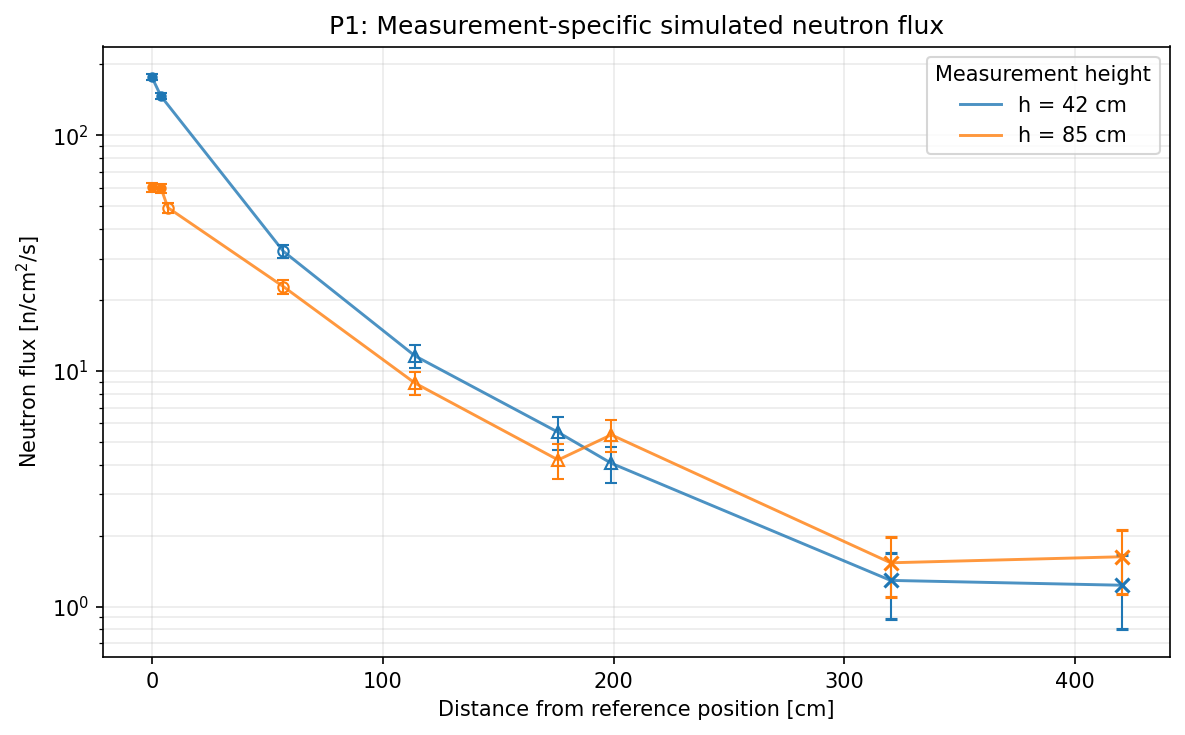

Saved figure: N2_simulated_neutron_outputs/figures/section_6_p1_neutron_flux_vs_distance.png


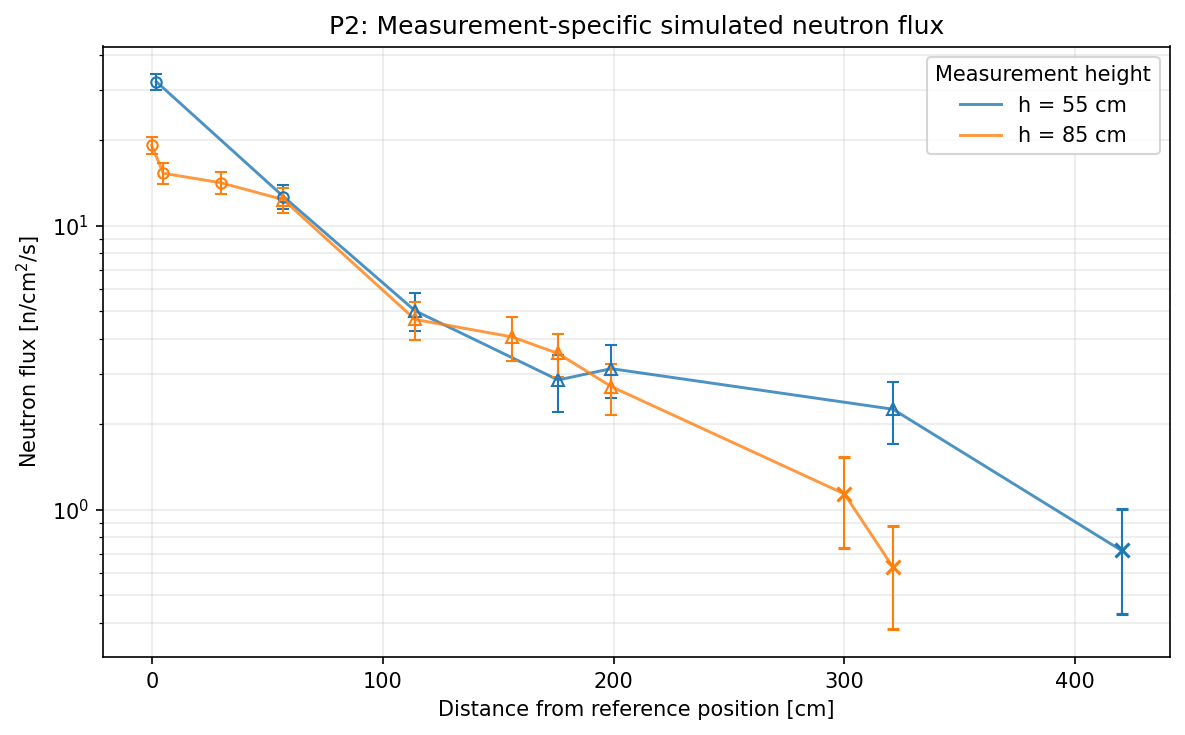

Saved figure: N2_simulated_neutron_outputs/figures/section_6_p2_neutron_flux_vs_distance.png


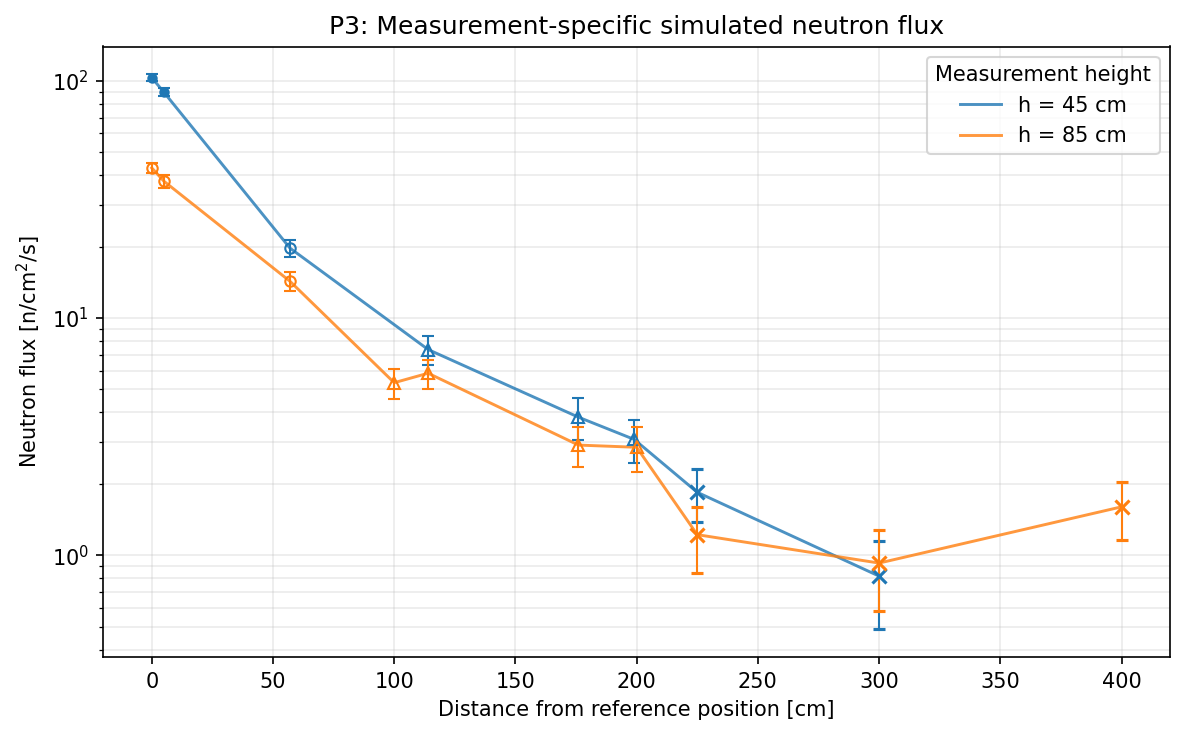

Saved figure: N2_simulated_neutron_outputs/figures/section_6_p3_neutron_flux_vs_distance.png


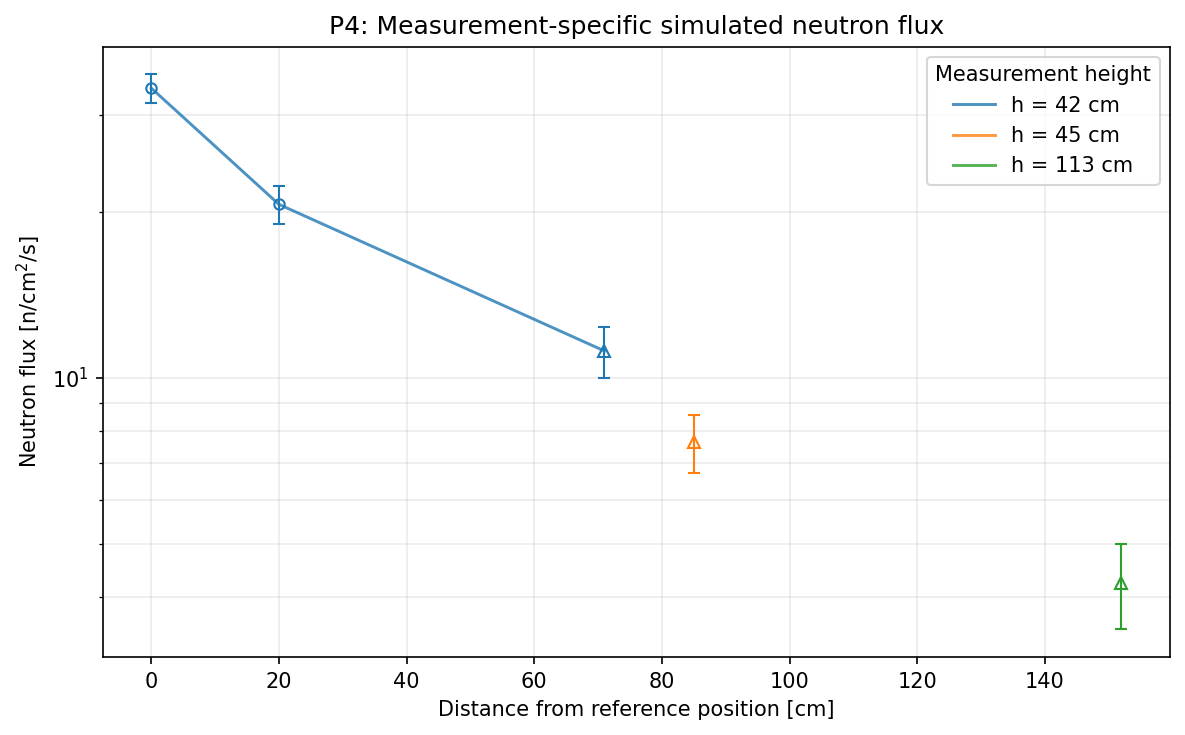

Saved figure: N2_simulated_neutron_outputs/figures/section_6_p4_neutron_flux_vs_distance.png


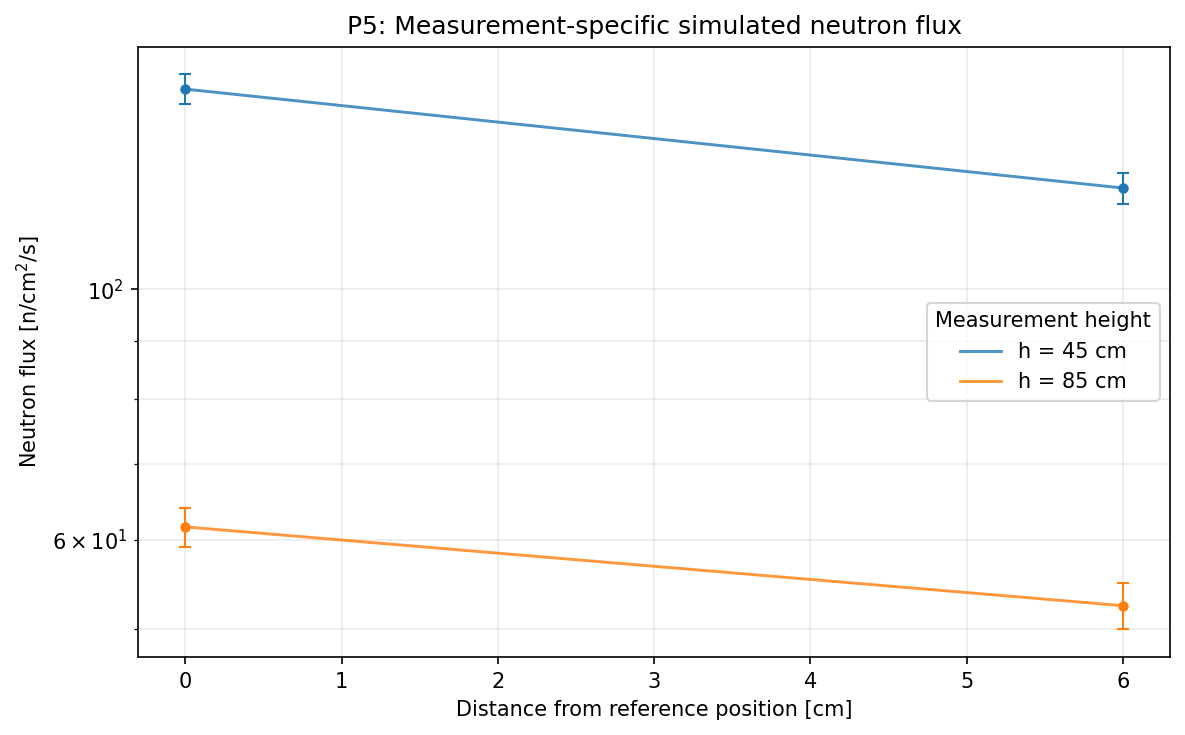

Saved figure: N2_simulated_neutron_outputs/figures/section_6_p5_neutron_flux_vs_distance.png


In [24]:
# ============================================
# 6) Measurement-specific neutron flux vs distance
# ============================================

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# ------------------------------------------------------------
# Output folder for all notebook figures
# ------------------------------------------------------------

OUTPUT_DIR = Path("N2_simulated_neutron_outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Check that post-processing has been run
# ------------------------------------------------------------

if "measurement_scan_summary" not in globals():
    raise NameError(
        "measurement_scan_summary was not found. "
        "Run Section 5 post-processing first."
    )

required_limits = [
    "MC_LOW_U_MAX_PERCENT",
    "MC_MODERATE_U_MAX_PERCENT",
    "MC_HIGH_U_MAX_PERCENT",
]

missing_limits = [
    name for name in required_limits
    if name not in globals()
]

if missing_limits:
    raise NameError(
        "The uncertainty limits were not found: "
        + ", ".join(missing_limits)
        + ". Run Section 5 first."
    )


# ------------------------------------------------------------
# Helper: plot one scan direction
# ------------------------------------------------------------

def plot_scan_direction(df, position):
    """
    Plot neutron flux versus distance for one scan direction.

    Different measurement heights are shown as separate curves.
    Marker shapes indicate the relative OpenMC standard uncertainty.
    """

    sub = df[df["position"] == position].copy()

    if sub.empty:
        print(f"No data found for {position}.")
        return

    fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

    heights = sorted(sub["height_cm"].unique())

    for height in heights:
        hdata = sub[
            sub["height_cm"] == height
        ].copy()

        hdata = hdata.sort_values("distance_cm")

        x = hdata["distance_cm"].to_numpy()
        y = hdata["flux_physical [n/cm2/s]"].to_numpy()
        yerr = hdata["u_mc_physical [n/cm2/s]"].to_numpy()
        rel_u_mc = hdata["rel_u_mc [%]"].to_numpy()

        # Plot the connecting line and retain its colour
        line, = ax.plot(
            x,
            y,
            linewidth=1.4,
            alpha=0.8,
            label=f"h = {height:.0f} cm",
        )

        line_color = line.get_color()

        # ----------------------------------------------------
        # Classify points using the limits defined in Section 5
        # ----------------------------------------------------

        finite_uncertainty = np.isfinite(rel_u_mc)

        low = (
            finite_uncertainty
            & (rel_u_mc < MC_LOW_U_MAX_PERCENT)
        )

        moderate = (
            finite_uncertainty
            & (rel_u_mc >= MC_LOW_U_MAX_PERCENT)
            & (rel_u_mc < MC_MODERATE_U_MAX_PERCENT)
        )

        high = (
            finite_uncertainty
            & (rel_u_mc >= MC_MODERATE_U_MAX_PERCENT)
            & (rel_u_mc < MC_HIGH_U_MAX_PERCENT)
        )

        very_high = (
            finite_uncertainty
            & (rel_u_mc >= MC_HIGH_U_MAX_PERCENT)
        )

        # Low uncertainty: filled circle
        if np.any(low):
            ax.errorbar(
                x[low],
                y[low],
                yerr=yerr[low],
                fmt="o",
                color=line_color,
                ecolor=line_color,
                capsize=3,
                markersize=4,
                linewidth=1.0,
            )

        # Moderate uncertainty: open circle
        if np.any(moderate):
            ax.errorbar(
                x[moderate],
                y[moderate],
                yerr=yerr[moderate],
                fmt="o",
                color=line_color,
                ecolor=line_color,
                mfc="none",
                capsize=3,
                markersize=5,
                linewidth=1.0,
            )

        # High uncertainty: open triangle
        if np.any(high):
            ax.errorbar(
                x[high],
                y[high],
                yerr=yerr[high],
                fmt="^",
                color=line_color,
                ecolor=line_color,
                mfc="none",
                capsize=3,
                markersize=6,
                linewidth=1.0,
            )

        # Very high uncertainty: cross
        if np.any(very_high):
            ax.errorbar(
                x[very_high],
                y[very_high],
                yerr=yerr[very_high],
                fmt="x",
                color=line_color,
                ecolor=line_color,
                capsize=3,
                markersize=7,
                markeredgewidth=1.5,
                linewidth=1.0,
            )

    ax.set_yscale("log")
    ax.set_xlabel("Distance from reference position [cm]")
    ax.set_ylabel(r"Neutron flux [n/cm$^2$/s]")
    ax.set_title(
        f"{position}: Measurement-specific simulated neutron flux"
    )
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(title="Measurement height")

    fig.tight_layout()

    figure_path = (
    FIGURE_DIR
    / f"section_6_{position.lower()}_neutron_flux_vs_distance.png")

    fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",)

    plt.show()
    plt.close(fig)

    print(f"Saved figure: {figure_path}")


# ------------------------------------------------------------
# Plot P1--P5 separately
# ------------------------------------------------------------

for position in ["P1", "P2", "P3", "P4", "P5"]:
    plot_scan_direction(
        measurement_scan_summary,
        position,
    )

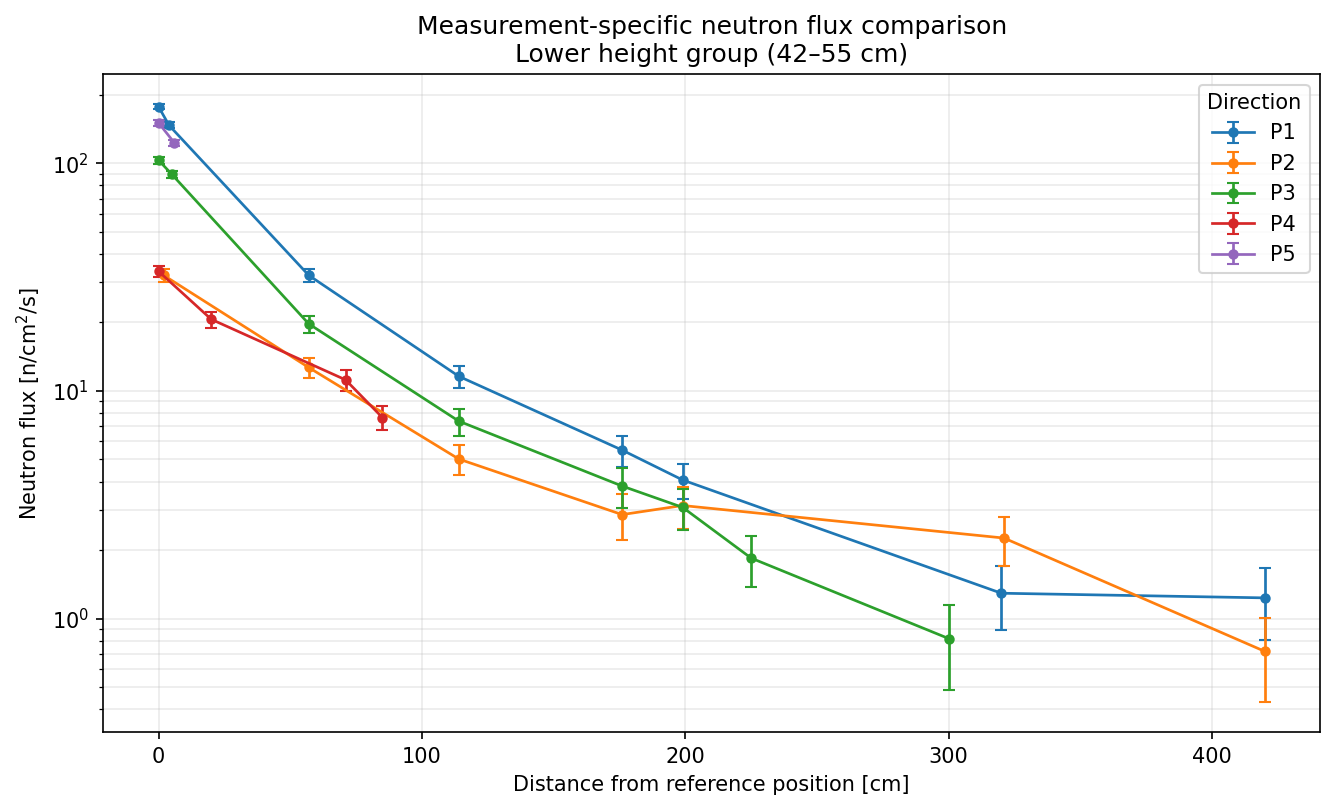

Saved figure: N2_simulated_neutron_outputs/figures/section_6_1_lower_height_42_55_cm_comparison.png


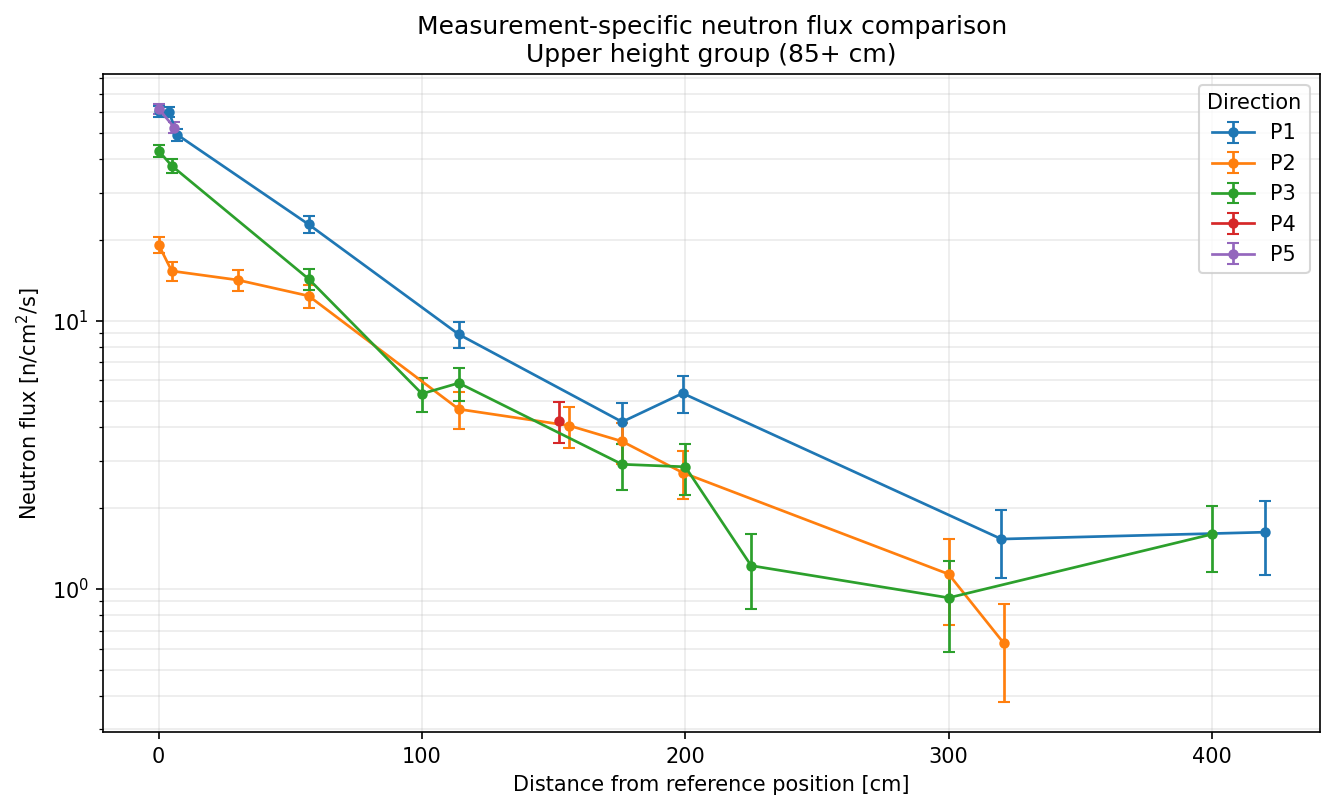

Saved figure: N2_simulated_neutron_outputs/figures/section_6_1_upper_height_85_plus_cm_comparison.png

Height-group summary:


,height_group,position,number_of_points
0,Lower height group (42–55 cm),P1,8
1,Lower height group (42–55 cm),P2,7
2,Lower height group (42–55 cm),P3,8
3,Lower height group (42–55 cm),P4,4
4,Lower height group (42–55 cm),P5,2
5,Upper height group (85+ cm),P1,9
6,Upper height group (85+ cm),P2,10
7,Upper height group (85+ cm),P3,10
8,Upper height group (85+ cm),P4,1
9,Upper height group (85+ cm),P5,2


In [20]:
# ====================================================
# 6.1) Combined direction comparison by height group
# ====================================================

import numpy as np
import matplotlib.pyplot as plt


def assign_height_group(height_cm):
    """
    Assign measurement height to a height group.

    Lower group:
        42--55 cm

    Upper group:
        85 cm and above
    """

    if 42.0 <= height_cm <= 55.0:
        return "Lower height group (42–55 cm)"

    if height_cm >= 85.0:
        return "Upper height group (85+ cm)"

    return "Other heights"


# ------------------------------------------------------------
# Add height-group column
# ------------------------------------------------------------

measurement_scan_summary_grouped = (
    measurement_scan_summary.copy()
)

measurement_scan_summary_grouped["height_group"] = (
    measurement_scan_summary_grouped["height_cm"]
    .apply(assign_height_group)
)


# ------------------------------------------------------------
# Plot helper
# ------------------------------------------------------------

def plot_height_group_comparison(
    df,
    height_group,
    filename_tag,
):
    """
    Plot and save all scan directions for one height group.
    """

    sub = df[
        df["height_group"] == height_group
    ].copy()

    if sub.empty:
        print(f"No data found for {height_group}.")
        return

    fig, ax = plt.subplots(
        figsize=(9, 5.5),
        dpi=150,
    )

    for position in sorted(sub["position"].unique()):
        pdata = sub[
            sub["position"] == position
        ].copy()

        pdata = pdata.sort_values("distance_cm")

        x = pdata["distance_cm"].to_numpy()
        y = pdata[
            "flux_physical [n/cm2/s]"
        ].to_numpy()
        yerr = pdata[
            "u_mc_physical [n/cm2/s]"
        ].to_numpy()

        ax.errorbar(
            x,
            y,
            yerr=yerr,
            marker="o",
            capsize=3,
            linewidth=1.3,
            markersize=4,
            label=position,
        )

    ax.set_yscale("log")

    ax.set_xlabel(
        "Distance from reference position [cm]"
    )

    ax.set_ylabel(
        r"Neutron flux [n/cm$^2$/s]"
    )

    ax.set_title(
        "Measurement-specific neutron flux comparison\n"
        f"{height_group}"
    )

    ax.grid(
        True,
        which="both",
        alpha=0.25,
    )

    ax.legend(title="Direction")

    fig.tight_layout()

    figure_path = (
        FIGURE_DIR
        / f"section_6_1_{filename_tag}_comparison.png"
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print(f"Saved figure: {figure_path}")


# ------------------------------------------------------------
# Make and save grouped comparison plots
# ------------------------------------------------------------

height_group_plots = [
    (
        "Lower height group (42–55 cm)",
        "lower_height_42_55_cm",
    ),
    (
        "Upper height group (85+ cm)",
        "upper_height_85_plus_cm",
    ),
]

for height_group, filename_tag in height_group_plots:
    plot_height_group_comparison(
        measurement_scan_summary_grouped,
        height_group,
        filename_tag,
    )


# ------------------------------------------------------------
# Print grouping summary
# ------------------------------------------------------------

print()
print("Height-group summary:")

display(
    measurement_scan_summary_grouped
    .groupby(
        ["height_group", "position"],
        observed=True,
    )
    .size()
    .rename("number_of_points")
    .reset_index()
)

Saved final neutron scan simulation table:
  Main folder:  measurement_specific_neutron_scan_summary_final.csv
  Table folder: N2_simulated_neutron_outputs/tables/measurement_specific_neutron_scan_summary_final.csv


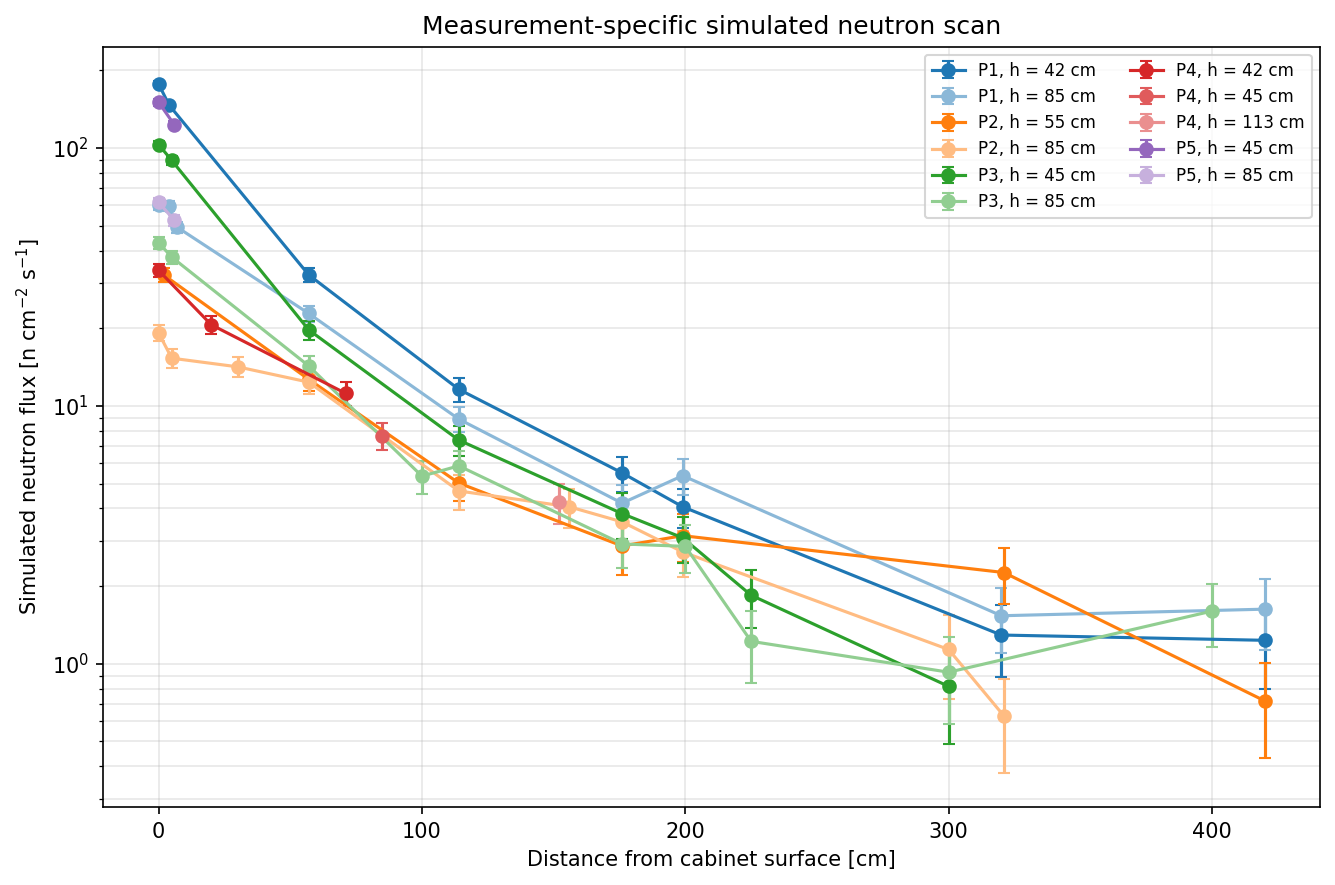

Saved figure: N2_simulated_neutron_outputs/figures/measurement_specific_neutron_flux_vs_distance.png


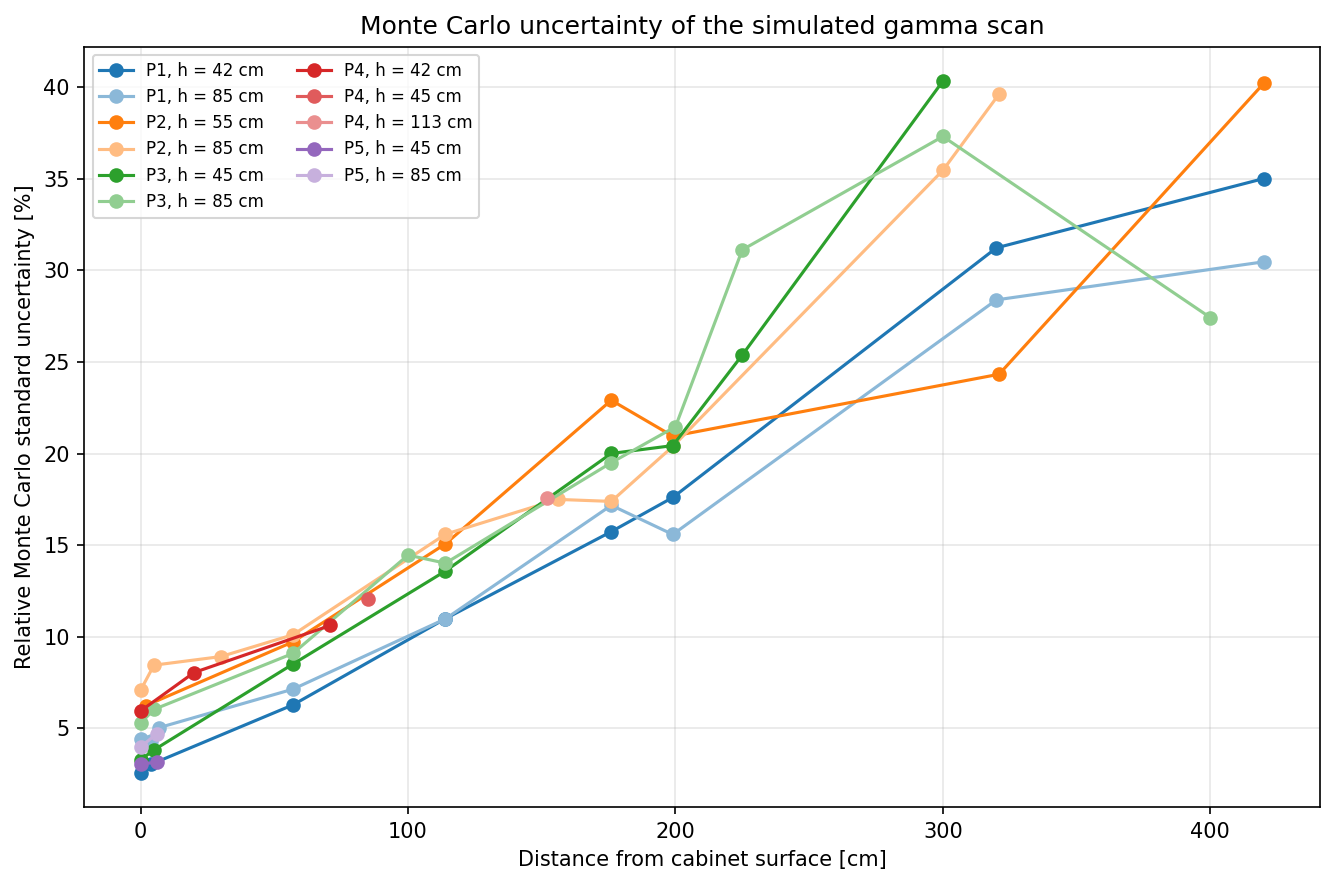

Saved figure: N2_simulated_neutron_outputs/figures/measurement_specific_neutron_relative_mc_uncertainty.png


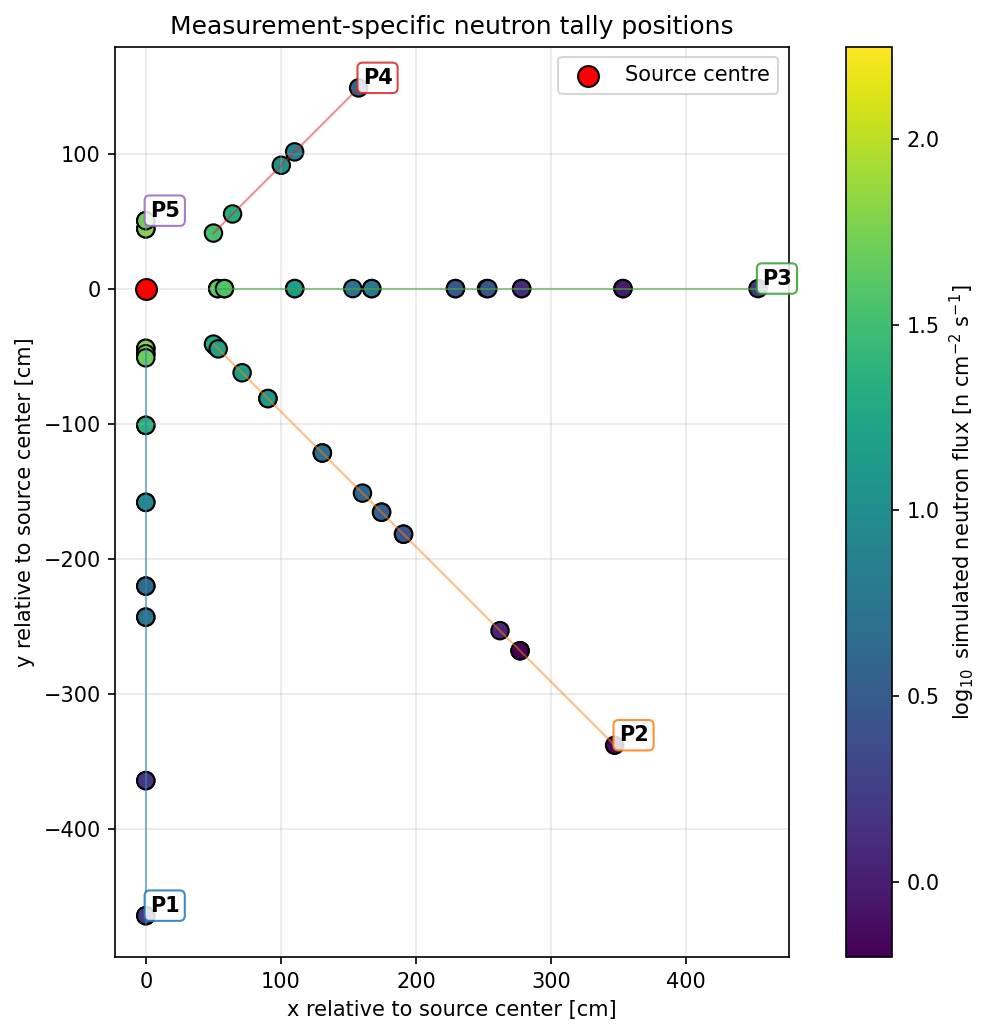

Saved figure: N2_simulated_neutron_outputs/figures/measurement_specific_neutron_scan_xy_map.png

Saved metadata:
  N2_simulated_neutron_outputs/metadata/measurement_specific_neutron_scan_metadata.csv

Total number of saved figures: 10
  N2_simulated_neutron_outputs/figures/measurement_specific_neutron_flux_vs_distance.png
  N2_simulated_neutron_outputs/figures/measurement_specific_neutron_relative_mc_uncertainty.png
  N2_simulated_neutron_outputs/figures/measurement_specific_neutron_scan_xy_map.png
  N2_simulated_neutron_outputs/figures/section_6_1_lower_height_42_55_cm_comparison.png
  N2_simulated_neutron_outputs/figures/section_6_1_upper_height_85_plus_cm_comparison.png
  N2_simulated_neutron_outputs/figures/section_6_p1_neutron_flux_vs_distance.png
  N2_simulated_neutron_outputs/figures/section_6_p2_neutron_flux_vs_distance.png
  N2_simulated_neutron_outputs/figures/section_6_p3_neutron_flux_vs_distance.png
  N2_simulated_neutron_outputs/figures/section_6_p4_neutron_flux_vs_distanc

In [29]:
# ============================================================
# Save final neutron scan outputs and recreate/save figures
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import to_rgb


# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

OUTPUT_DIR = Path(
    "N2_simulated_neutron_outputs"
)

TABLE_DIR = (
    OUTPUT_DIR
    / "tables"
)

FIGURE_DIR = (
    OUTPUT_DIR
    / "figures"
)

METADATA_DIR = (
    OUTPUT_DIR
    / "metadata"
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

METADATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Save final tables
# ------------------------------------------------------------

final_output_csv = Path(
    "measurement_specific_neutron_scan_summary_final.csv"
)

final_output_csv_folder = (
    TABLE_DIR
    / "measurement_specific_neutron_scan_summary_final.csv"
)

measurement_scan_summary.to_csv(
    final_output_csv,
    index=False,
)

measurement_scan_summary.to_csv(
    final_output_csv_folder,
    index=False,
)

print(
    "Saved final neutron scan simulation table:"
)

print(
    f"  Main folder:  {final_output_csv}"
)

print(
    f"  Table folder: {final_output_csv_folder}"
)


# ------------------------------------------------------------
# Helper columns
# ------------------------------------------------------------

flux_col = (
    "flux_physical [n/cm2/s]"
)

u_mc_col = (
    "u_mc_physical [n/cm2/s]"
)

rel_u_mc_col = (
    "rel_u_mc [%]"
)

df = measurement_scan_summary.copy()

df["height_label"] = df[
    "height_cm"
].apply(
    lambda h: f"h = {h:g} cm"
)


# ------------------------------------------------------------
# Position colours
# ------------------------------------------------------------

# Use the same position colours as in the gamma notebook.
# Existing colours are preserved if position_colors was
# already defined in an earlier cell.

if "position_colors" not in globals():
    position_colors = {
        "P1": "tab:blue",
        "P2": "tab:orange",
        "P3": "tab:green",
        "P4": "tab:red",
        "P5": "tab:purple",
    }


missing_position_colors = sorted(
    set(
        df["position"].dropna()
    )
    - set(position_colors)
)

if missing_position_colors:
    raise KeyError(
        "No colour has been defined in position_colors for: "
        + ", ".join(missing_position_colors)
    )


def lighten_color(
    color,
    amount,
):
    """
    Blend a colour with white.

    Parameters
    ----------
    color : matplotlib-compatible colour
        Base colour assigned to the position.

    amount : float
        Fraction of white mixed into the base colour.
        A value of 0 returns the original colour.
    """

    base_rgb = np.asarray(
        to_rgb(color),
        dtype=float,
    )

    white_rgb = np.ones(3)

    return tuple(
        (1.0 - amount) * base_rgb
        + amount * white_rgb
    )


# Create a separate shade for each position-height
# combination. The lowest height uses the darkest shade.

position_height_colors = {}

for position, position_data in df.groupby(
    "position",
    sort=True,
):
    available_heights = np.sort(
        position_data[
            "height_cm"
        ]
        .dropna()
        .unique()
    )

    number_of_heights = len(
        available_heights
    )

    if number_of_heights == 1:
        lightening_amounts = np.array(
            [0.0]
        )

    else:
        lightening_amounts = np.linspace(
            0.0,
            0.48,
            number_of_heights,
        )

    for (
        height_cm,
        lightening_amount,
    ) in zip(
        available_heights,
        lightening_amounts,
    ):
        position_height_colors[
            (position, height_cm)
        ] = lighten_color(
            position_colors[position],
            lightening_amount,
        )


# ------------------------------------------------------------
# Figure 1: neutron flux vs distance for each position
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 6),
    dpi=150,
)

for (
    position,
    height_cm,
), group in df.groupby(
    [
        "position",
        "height_cm",
    ],
    sort=True,
):
    group = group.sort_values(
        "distance_cm"
    )

    curve_color = position_height_colors[
        (position, height_cm)
    ]

    ax.errorbar(
        group["distance_cm"],
        group[flux_col],
        yerr=group[u_mc_col],
        marker="o",
        linestyle="-",
        capsize=3,
        color=curve_color,
        label=(
            f"{position}, "
            f"h = {height_cm:g} cm"
        ),
    )

ax.set_yscale(
    "log"
)

ax.set_xlabel(
    "Distance from cabinet surface [cm]"
)

ax.set_ylabel(
    r"Simulated neutron flux "
    r"[n cm$^{-2}$ s$^{-1}$]"
)

ax.set_title(
    "Measurement-specific simulated neutron scan"
)

ax.grid(
    True,
    which="both",
    alpha=0.3,
)

ax.legend(
    fontsize=8,
    ncol=2,
)

fig.tight_layout()

fig_path = (
    FIGURE_DIR
    / "measurement_specific_neutron_flux_vs_distance.png"
)

fig.savefig(
    fig_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved figure: {fig_path}"
)


# ------------------------------------------------------------
# Figure 2: relative Monte Carlo uncertainty vs distance
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 6),
    dpi=150,
)

for (
    position,
    height_cm,
), group in df.groupby(
    [
        "position",
        "height_cm",
    ],
    sort=True,
):
    group = group.sort_values(
        "distance_cm"
    )

    curve_color = position_height_colors[
        (position, height_cm)
    ]

    ax.plot(
        group["distance_cm"],
        group[rel_u_mc_col],
        marker="o",
        linestyle="-",
        color=curve_color,
        label=(
            f"{position}, "
            f"h = {height_cm:g} cm"
        ),
    )

ax.set_xlabel(
    "Distance from cabinet surface [cm]"
)

ax.set_ylabel(
    "Relative Monte Carlo standard uncertainty [%]"
)

ax.set_title(
    "Monte Carlo uncertainty of the simulated gamma scan"
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend(
    fontsize=8,
    ncol=2,
)

fig.tight_layout()

fig_path = (
    FIGURE_DIR
    / "measurement_specific_neutron_relative_mc_uncertainty.png"
)

fig.savefig(
    fig_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved figure: {fig_path}"
)


# ------------------------------------------------------------
# Figure 3: spatial XY view of tally points, coloured by flux
#           with one label per position/direction
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 7),
    dpi=150,
)

scatter = ax.scatter(
    df["x_cm"],
    df["y_cm"],
    c=np.log10(
        df[flux_col]
    ),
    s=70,
    edgecolor="black",
)


# ------------------------------------------------------------
# Add only one label per position
# Use the outermost point in each direction
# ------------------------------------------------------------

for position, group in df.groupby(
    "position",
    sort=True,
):
    group = group.sort_values(
        "distance_cm"
    )

    position_color = position_colors[
        position
    ]

    # Pick the point farthest away in that position.
    label_row = group.iloc[-1]

    ax.text(
        label_row["x_cm"] + 3.0,
        label_row["y_cm"] + 3.0,
        position,
        fontsize=10,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "white",
            "edgecolor": position_color,
            "alpha": 0.85,
        },
    )

    # Draw a thin line showing the direction.
    ax.plot(
        group["x_cm"],
        group["y_cm"],
        color=position_color,
        linewidth=1.0,
        alpha=0.5,
    )


# Mark the source centre.

ax.scatter(
    [0.0],
    [0.0],
    s=100,
    color="red",
    edgecolor="black",
    label="Source centre",
    zorder=5,
)

cbar = fig.colorbar(
    scatter,
    ax=ax,
)

cbar.set_label(
    r"$\log_{10}$ simulated neutron flux "
    r"[n cm$^{-2}$ s$^{-1}$]"
)

ax.set_xlabel(
    "x relative to source center [cm]"
)

ax.set_ylabel(
    "y relative to source center [cm]"
)

ax.set_title(
    "Measurement-specific neutron tally positions"
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.grid(
    alpha=0.3
)

ax.legend()

fig.tight_layout()

fig_path = (
    FIGURE_DIR
    / "measurement_specific_neutron_scan_xy_map.png"
)

fig.savefig(
    fig_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved figure: {fig_path}"
)


# ------------------------------------------------------------
# Save metadata
# ------------------------------------------------------------

metadata_df = pd.DataFrame(
    [
        {
            "quantity": "number_of_scan_points",
            "value": len(df),
            "unit": "points",
        },
        {
            "quantity": "source_manufacturer",
            "value": SOURCE_MANUFACTURER,
            "unit": "",
        },
        {
            "quantity": "source_model",
            "value": SOURCE_MODEL,
            "unit": "",
        },
        {
            "quantity": "source_serial_number",
            "value": SOURCE_SERIAL_NUMBER,
            "unit": "",
        },
        {
            "quantity": (
                "factory_neutron_emission_reference"
            ),
            "value": SOURCE_NEUTRON_EMISSION_REF,
            "unit": "n/s",
        },
        {
            "quantity": (
                "factory_neutron_emission_reference_date"
            ),
            "value": SOURCE_NEUTRON_EMISSION_REF_DATE,
            "unit": "",
        },
        {
            "quantity": "selected_neutron_emission",
            "value": SOURCE_NEUTRON_EMISSION,
            "unit": "n/s",
        },
        {
            "quantity": (
                "selected_neutron_emission_date"
            ),
            "value": SOURCE_EVALUATION_DATE,
            "unit": "",
        },
        {
            "quantity": (
                "source_normalization_status"
            ),
            "value": SOURCE_NORMALIZATION_STATUS,
            "unit": "",
        },
        {
            "quantity": (
                "factory_neutron_emission_"
                "standard_uncertainty"
            ),
            "value": np.nan,
            "unit": "n/s (not reported)",
        },
        {
            "quantity": (
                "historical_moderated_local_"
                "thermal_flux"
            ),
            "value": HISTORICAL_LOCAL_THERMAL_FLUX,
            "unit": "n/cm2/s",
        },
        {
            "quantity": (
                "historical_local_thermal_flux_"
                "standard_uncertainty"
            ),
            "value": np.nan,
            "unit": "n/cm2/s (unknown)",
        },
        {
            "quantity": (
                "reported_flux_uncertainty_scope"
            ),
            "value": (
                "OpenMC batch-statistical "
                "standard uncertainty only"
            ),
            "unit": "",
        },
        {
            "quantity": (
                "scan_detector_side_length"
            ),
            "value": SCAN_DET_SIZE,
            "unit": "cm",
        },
        {
            "quantity": "scan_detector_volume",
            "value": SCAN_DET_SIZE**3,
            "unit": "cm3",
        },
        {
            "quantity": "table_output",
            "value": str(
                final_output_csv_folder
            ),
            "unit": "",
        },
        {
            "quantity": (
                "figure_output_folder"
            ),
            "value": str(FIGURE_DIR),
            "unit": "",
        },
    ]
)

metadata_path = (
    METADATA_DIR
    / "measurement_specific_neutron_scan_metadata.csv"
)

metadata_df.to_csv(
    metadata_path,
    index=False,
)

print()

print(
    "Saved metadata:"
)

print(
    f"  {metadata_path}"
)


# ------------------------------------------------------------
# List all saved figures
# ------------------------------------------------------------

saved_figure_paths = sorted(
    FIGURE_DIR.glob("*.png")
)

print()

print(
    "Total number of saved figures: "
    f"{len(saved_figure_paths)}"
)

for figure_path in saved_figure_paths:
    print(
        f"  {figure_path}"
    )

# 7) Monte Carlo uncertainty check

The quality flag in Section 5 classifies the relative OpenMC
standard uncertainty as:

- good: $σ_{\mathrm{rel}} < 5\%$;
- moderate: $5\% \leq σ_{\mathrm{rel}} < 10\%$;
- high: $10\% \leq σ_{\mathrm{rel}} < 25\%$;
- very high: $σ_{\mathrm{rel}} \geq 25\%$.

These classes assess only tally precision. They do not describe the complete
simulation uncertainty and do not include an uncertainty for the factory source
strength or the historical moderated local thermal-flux measurement.

The farthest points, particularly at approximately 300--420 cm, are expected to
have the largest Monte Carlo uncertainty because relatively few simulated
neutrons contribute to their small tally volumes.

And the points with very high Monte Carlo uncertainty are retained for
completeness, but they should be interpreted qualitatively and
should not be used for strong quantitative conclusions.


In [26]:
uncertainty_class_counts = (
    measurement_scan_summary
    .groupby(
        ["position", "mc_uncertainty_class"],
        observed=True,
    )
    .size()
    .rename("count")
    .reset_index()
)

display(uncertainty_class_counts)


very_high_uncertainty_points = (
    measurement_scan_summary.loc[
        measurement_scan_summary["mc_uncertainty_class"] == "very high",
        [
            "position",
            "point_name",
            "distance_cm",
            "height_cm",
            "flux_physical [n/cm2/s]",
            "u_mc_physical [n/cm2/s]",
            "rel_u_mc [%]",
            "mc_uncertainty_class",
        ],
    ]
    .sort_values(
        ["position", "height_cm", "distance_cm"]
    )
    .reset_index(drop=True)
)

print()
print(
    "Number of points with relative Monte Carlo "
    f"uncertainty >= 25%: {len(very_high_uncertainty_points)}"
)

if not very_high_uncertainty_points.empty:
    display(very_high_uncertainty_points)

,position,mc_uncertainty_class,count
0,P1,low,4
1,P1,moderate,3
2,P1,high,6
3,P1,very high,4
4,P2,moderate,5
5,P2,high,9
6,P2,very high,3
7,P3,low,2
8,P3,moderate,4
9,P3,high,7



Number of points with relative Monte Carlo uncertainty >= 25%: 12


,position,point_name,distance_cm,height_cm,flux_physical [n/cm2/s],u_mc_physical [n/cm2/s],rel_u_mc [%],mc_uncertainty_class
0,P1,P1_x320_h42,320.0,42.0,1.292305,0.403593,31.230477,very high
1,P1,P1_x420_h42,420.0,42.0,1.232881,0.431670,35.013098,very high
2,P1,P1_x320_h85,320.0,85.0,1.535106,0.435838,28.391430,very high
3,P1,P1_x420_h85,420.0,85.0,1.628200,0.496100,30.469252,very high
4,P2,P2_x420_h55,420.0,55.0,0.717974,0.288722,40.213519,very high
5,P2,P2_x300_h85,300.0,85.0,1.135898,0.402825,35.463147,very high
6,P2,P2_x321_h85,321.0,85.0,0.627210,0.248508,39.621230,very high
7,P3,P3_x225_h45,225.0,45.0,1.843399,0.467933,25.384235,very high
8,P3,P3_x300_h45,300.0,45.0,0.817083,0.329553,40.332829,very high
9,P3,P3_x225_h85,225.0,85.0,1.221781,0.380284,31.125361,very high


# 8) Save final processed simulation output

In [27]:
# ============================================================
# Save final neutron scan outputs
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("N2_simulated_neutron_outputs")
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Save final table
# ------------------------------------------------------------

final_output_csv = Path("measurement_specific_neutron_scan_summary_final.csv")
final_output_csv_in_folder = TABLE_DIR / "measurement_specific_neutron_scan_summary_final.csv"

measurement_scan_summary.to_csv(final_output_csv, index=False)
measurement_scan_summary.to_csv(final_output_csv_in_folder, index=False)

print("Saved final neutron scan simulation table:")
print(f"  Main folder: {final_output_csv}")
print(f"  Table folder: {final_output_csv_in_folder}")


# ------------------------------------------------------------
# Save figures
# ------------------------------------------------------------
# This saves all currently open matplotlib figures.
# Therefore this cell should be run after the plotting cells.

open_figures = list(map(plt.figure, plt.get_fignums()))

if len(open_figures) == 0:
    print()
    print("No open matplotlib figures found.")
    print("Run the plotting cells first, then rerun this save cell.")
else:
    print()
    print("Saved neutron scan figures:")

    for i, fig in enumerate(open_figures, start=1):
        figure_path = FIGURE_DIR / f"neutron_scan_figure_{i:02d}.png"
        fig.savefig(figure_path, dpi=300, bbox_inches="tight")
        print(f"  {figure_path}")


# ------------------------------------------------------------
# Optional metadata
# ------------------------------------------------------------

metadata_rows = [
    {
        "quantity": "number_of_scan_points",
        "value": len(measurement_scan_summary),
        "unit": "points",
    },
    {
        "quantity": "source",
        "value": f"{SOURCE_MODEL}, {SOURCE_SERIAL_NUMBER}",
        "unit": "",
    },
    {
        "quantity": "factory_neutron_emission_reference",
        "value": SOURCE_NEUTRON_EMISSION_REF,
        "unit": "n/s",
    },
    {
        "quantity": "factory_neutron_emission_reference_date",
        "value": SOURCE_NEUTRON_EMISSION_REF_DATE,
        "unit": "",
    },
    {
        "quantity": "selected_neutron_emission",
        "value": SOURCE_NEUTRON_EMISSION,
        "unit": "n/s",
    },
    {
        "quantity": "selected_neutron_emission_date",
        "value": SOURCE_EVALUATION_DATE,
        "unit": "",
    },
    {
        "quantity": "historical_moderated_local_thermal_flux",
        "value": HISTORICAL_LOCAL_THERMAL_FLUX,
        "unit": "n/cm2/s; uncertainty unknown",
    },
    {
        "quantity": "exported_uncertainty_scope",
        "value": "OpenMC batch-statistical standard uncertainty only",
        "unit": "",
    },
    {
        "quantity": "output_table_main_folder",
        "value": str(final_output_csv),
        "unit": "",
    },
    {
        "quantity": "output_table_folder",
        "value": str(final_output_csv_in_folder),
        "unit": "",
    },
    {
        "quantity": "figure_folder",
        "value": str(FIGURE_DIR),
        "unit": "",
    },
]

neutron_scan_metadata_df = pd.DataFrame(metadata_rows)
metadata_path = TABLE_DIR / "neutron_scan_metadata.csv"
neutron_scan_metadata_df.to_csv(metadata_path, index=False)

print()
print("Saved metadata:")
print(f"  {metadata_path}")

Saved final neutron scan simulation table:
  Main folder: measurement_specific_neutron_scan_summary_final.csv
  Table folder: N2_simulated_neutron_outputs/tables/measurement_specific_neutron_scan_summary_final.csv

No open matplotlib figures found.
Run the plotting cells first, then rerun this save cell.

Saved metadata:
  N2_simulated_neutron_outputs/tables/neutron_scan_metadata.csv


# 9) Summary and conclusion

This notebook calculated the theoretical neutron flux at the measurement-specific P1–P5 scan positions using the shared OpenMC Am–Be source geometry established in Notebook 1. The model includes the Am–Be neutron source spectrum, the paraffin moderator, the steel cabinet, the hollow sample tubes, the steel rods, the L-shaped lead shielding blocks and the measurement-specific tally volumes.

The OpenMC simulation used 200 batches with 100,000 source particles per batch, corresponding to a total of

$$
200\times100{,}000=2.0\times10^7
$$

simulated source particles. In total, 61 scan tallies were processed: 17 for P1, 17 for P2, 18 for P3, 5 for P4 and 4 for P5. Each tally represents the volume-averaged neutron flux within a $2\times2\times2\ \mathrm{cm^3}$ detector volume.

The physical source is the Amersham AMN 24 source with serial number AMN 5000/1365. Its factory test report gives a neutron emission rate of $1.20\times10^7\ \mathrm{n,s^{-1}}$ on 5 July 1968. Using the half-life of ${}^{241}\mathrm{Am}$, this central value was decay-corrected to $1.094\times10^7\ \mathrm{n,s^{-1}}$ on 15 March 2026 and used to convert the per-source OpenMC tallies to physical neutron flux. The historical moderated local thermal flux of approximately $2.3\times10^4\ \mathrm{n,cm^{-2},s^{-1}}$ was retained only as contextual information and was not used for source normalization.

The simulated neutron flux generally decreases strongly with increasing distance from the cabinet. Values close to the cabinet are typically of the order of $10^1$–$10^2\ \mathrm{n,cm^{-2},s^{-1}}$, whereas the most distant positions approach approximately $10^0\ \mathrm{n,cm^{-2},s^{-1}}$. The lower measurement-height group, covering 42–55 cm, generally produces a higher near-cabinet flux than the upper group at 85 cm and above.

Differences between P1–P5 and between measurement heights demonstrate that the neutron field is spatially non-uniform. This is consistent with the asymmetric cabinet geometry and the combined effects of moderation, absorption, scattering and leakage. Because the scan directions do not contain identical sets of distances and heights, the observed directional differences should be interpreted as characteristics of the complete measurement geometry rather than as isolated angular effects.

At large distances, some curves flatten or show small increases instead of continuing to decrease monotonically. These variations coincide with larger error bars and should not be interpreted as evidence of a physical increase in neutron flux. They primarily indicate that relatively few simulated particle histories contribute to the distant tally volumes.

Of the 61 tally points, 10 were classified as having low relative Monte Carlo uncertainty, 14 as moderate, 25 as high and 12 as very high. The 12 very-high-uncertainty points, for which $u_{\mathrm{rel,MC}}\geq25%$, occur in P1–P3 at distances between 225 and 420 cm. These points are retained to document the complete simulated scan, but they should be used primarily for qualitative interpretation and should receive less weight in subsequent comparisons with measurements. The points closer to the cabinet provide the most statistically reliable description of the spatial neutron-flux distribution.

The reported uncertainties represent only the OpenMC batch-statistical standard uncertainty. They do not include uncertainty in the factory source strength, decay correction, source spectrum, material compositions, geometry or detector response. Since the available source documentation does not report a standard uncertainty for the factory neutron-emission result, the calculated error bars must not be interpreted as the total uncertainty of the absolute physical neutron flux.

Overall, Notebook 2 successfully establishes a measurement-specific theoretical neutron-flux dataset for the P1–P5 positions. The results reproduce the expected overall attenuation with distance while also showing height- and direction-dependent variations caused by the source arrangement and surrounding geometry. The final results were exported to `measurement_specific_neutron_scan_summary_final.csv`, together with the associated metadata and figures. These outputs provide the basis for the later simulation-to-measurement comparison (provided that the Monte Carlo uncertainty classes and the currently unquantified model and normalization uncertainties are considered when drawing quantitative conclusions).
